# **Programación Evolutiva y Problemas Multiobjetivo**
## **NSGA-II: Frente de Pareto**

**Fecha**      : 24-03-2026

**Grupo No**  : 2

**Autores:**
- Rodríguez Vélez Ximena Jhoana
- Sánchez Mendieta Juan Pablo
- Viteri Ayala Flavia Kamila

**Objetivo del notebook:**

Este notebook implementa y ejecuta el problema de optimización multiobjetivo
comparando la versión original con la versión implementada por el equipo 
usando el algoritmo NSGA-II con la librería `pymoo`.

Cada sección ejecuta ambas versiones y visualiza los resultados lado a lado 
para facilitar la comparación.

**Contexto del problema:**

Somos directivos de una empresa y queremos simultáneamente:
- **Maximizar** el Rendimiento Financiero (**RF**)
- **Minimizar** los Gastos Administrativos (**GA**)

Tomando en cuenta las siguientes variables:
- **x1 = NIT**: Nivel de Inversión en Nuevas Tecnologías
- **x2 = GES**: Grado de Externalización de Servicios

---
## **Sección 1 — Instalación y carga de librerías**

En esta sección se instala `pymoo` y se importa todas las dependencias necesarias.  

Se usa pymoo porque es el framework estándar en Python para optimización multiobjetivo 
con algoritmos evolutivos; provee implementaciones eficientes de NSGA-II, operadores 
genéticos y utilidades de visualización.

Con esto, se tiene un entorno reproducible con todas las herramientas antes de definir 
ningún problema.

In [1]:
# ── Importaciones estándar ────────────────────────────────────────────────────
import os                                   # Manejo de directorios
import numpy as np                          # Operaciones numéricas
import matplotlib.pyplot as plt             # Visualización
import matplotlib.gridspec as gridspec      # Control fino de layouts de figuras
import matplotlib.patches as mpatches


# ── Importaciones de pymoo ────────────────────────────────────────────────────
from pymoo.core.problem import ElementwiseProblem   # Clase base para definir problemas
from pymoo.algorithms.moo.nsga2 import NSGA2        # Algoritmo NSGA-II
from pymoo.optimize import minimize                  # Función principal de optimización
from pymoo.visualization.scatter import Scatter

# ── Semilla global para reproducibilidad ─────────────────────────────────────
SEED = 1

# ── Directorio de salida para figuras ────────────────────
os.makedirs('outputs', exist_ok=True)

print("✅ Librerías cargadas correctamente.")
import pymoo; print(f"   pymoo versión: {pymoo.__version__}")

✅ Librerías cargadas correctamente.
   pymoo versión: 0.6.1.6


---
## **Sección 2 — Definición del problema**

En NSGA-II (y en pymoo en general), definir el "problema" es el primer 
paso obligatorio, pues le decimos al algoritmo qué variables controla, 
qué se quiere optimizar y bajo qué restricciones. Sin esta definición, 
el algoritmo no sabe en qué espacio buscar ni qué es "bueno".

<hr style="border: 1px dashed #3498db;">


### **Situación ficticia:**

Una empresa de servicios financieros debe decidir cómo distribuir sus recursos
entre dos palancas estratégicas:

- **NIT (`x1`) — Nivel de Inversión Tecnológica**: cuánto invierte en
  infraestructura digital, automatización y sistemas internos propios.
- **GES (`x2`) — Grado de Externalización de Servicios**: cuánto
  delega a proveedores externos (contabilidad, soporte, operaciones back-office).

El reto es encontrar la combinación de `x1` y `x2` que logre **simultáneamente**:

- **Maximizar el Rendimiento Financiero (RF):** mayor inversión tecnológica
  impulsa el retorno, pero con rendimientos que se van agotando a medida que
  `x1` crece.
- **Minimizar los Gastos Administrativos (GA):** externalizar más reduce costes
  directos, pero alejarse del punto óptimo de integración (`x1 = 5`) los dispara.

**¿Cuál es el conflicto?**

Estos dos objetivos se contraponen de forma natural, ya que cualquier decisión que
mejora la rentabilidad tiende a encarecer la operación, y viceversa. Por eso
no existe una solución única perfecta, sino una **frontera de Pareto** con
múltiples soluciones de compromiso eficientes entre las que el directivo deberá
elegir según las prioridades de la empresa.

<hr style="border: 1px dashed #3498db;">

### **Problema Original:** 

En este problema existen dos objetivos en conflicto:

**1. Maximizar el Rendimiento Financiero (RF):** `RF = (x1+1)² + 0.5·x2 − 0.1·x2²`
- Subir el nivel de inversión tecnológica (`x1`) siempre mejora el RF (relación cuadrática sin techo). 
- La externalización de servicios (`x2`) ayuda al principio pero tiene rendimientos decrecientes.

**2.Minimizar GA (Gastos Administrativos):** `GA = 50/(x2+1) + 0.2·(x1−5)² + 5`

- Más externalización (`x2` alto) reduce los gastos directos. 
- Pero alejarse de `x1=5` dispara los costos.

**¿Existen restricciones?**

En el ejercicio original no existen restricciones, el espacio de búsqueda es el cuadrado completo [0,10]×[0,10].

<hr style="border: 1px dashed #3498db;">

### **Problema Modificado:** 

En el problema que plantea el equipo, se añaden algunos cambios realistas:

**1. RF con rendimientos decrecientes (se cambia de fórmula):** `RF_nuevo = 10·√(x1+1) + 0.5·x2 − 0.1·x2²`

El cambio de `(x1+1)²` a `10·√(x1+1)` modela una **saturación tecnológica** donde:
- Las primeras inversiones en tecnología son muy rentables, pero cada unidad adicional aporta menos. 
- Un modelo más realista que el crecimiento cuadrático ilimitado del original.

**2. Restricción presupuestaria:** `x1 + 0.8·x2 ≤ 12`

- No se puede invertir ilimitadamente. 
- El presupuesto total es 12 unidades. 
- Esto elimina las soluciones "trampa" donde `x1=10` y `x2=10` simultáneamente.

<span style="color:rgb(231, 60, 60); font-weight: bold;">Se modelan dos restricciones adicionales:</span> <span style="color:rgb(123, 231, 60); font-weight: bold;">Ítem extra</span>

**3. Restricción operativa:** `2 − x1 ≤ 0`
 - Existe una inversión en nueva tecnología mínima obligatoria.
 - La empresa debe mantener un nivel mínimo de digitalización para cumplir requisitos regulatorios y contractuales.
 - No es viable externalizar servicios sin tener una base tecnológica propia que lo respalde.

**4. Restricción de riesgo:** `x2 − 2·x1 ≤ 0`
- Control sobre la externalización.
- Externalizar servicios requiere capacidad interna para supervisar y coordinar a los proveedores.
- Si el grado de externalización supera el doble del nivel tecnológico interno, la empresa pierde 
control operativo sobre los procesos externalizados.
- En otras palabras: se puede externalizar más solo si se tiene más tecnología propia que lo sustente.

Esta versión es más realista porque impone que los recursos son finitos, que la tecnología tiene retornos 
decrecientes, que existe un umbral mínimo de digitalización no negociable, y que la externalización no puede 
crecer descontroladamente sin una base tecnológica interna que la gobierne.

### **¿Qué se quiere resolver en última instancia?** 

Ambos problemas buscan responder: <span style="color:rgb(231, 60, 60); font-weight: bold;">¿Cuánto se debe invertir en tecnología (`x1`) y cuánto externalizar (`x2`) para obtener el mejor 
balance posible entre rentabilidad y eficiencia en costes?</span>

### **¿Qué devuelve el NSGA-II?** 

Este algoritmo no devuelve una sola respuesta sino una **frontera de Pareto**, es decir, 
un conjunto de soluciones donde mejorar un objetivo implica empeorar el otro. 

El tomador de decisiones (un directivo, en este caso) elige el punto de esa 
frontera que mejor refleja las prioridades de su empresa.

In [2]:
# ==============================================================================
# PROBLEMA ORIGINAL — sin restricciones adicionales
# ==============================================================================
class ProblemaFinancieroOriginal(ElementwiseProblem):
    """
    Version de referencia (enunciado base).
    RF(x1,x2) = (x1+1)^2 + 0.5*x2 - 0.1*x2^2   -> maximizar
    GA(x1,x2) = 50/(x2+1) + 0.2*(x1-5)^2 + 5    -> minimizar
    Sin restricciones de desigualdad.
    """
    def __init__(self):
        super().__init__(
            n_var=2, n_obj=2, n_constr=0,
            xl=np.array([0.0, 0.0]),
            xu=np.array([10.0, 10.0])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]
        # RF: crecimiento cuadratico con NIT; x2 tiene impacto positivo pero decreciente
        rf   = (x1 + 1)**2 + 0.5 * x2 - 0.1 * x2**2
        obj1 = -rf   # negamos para maximizar
        # GA: disminuye con GES; se penaliza alejarse del NIT optimo (~5)
        ga   = 50 / (x2 + 1) + 0.2 * (x1 - 5)**2 + 5
        obj2 = ga
        out["F"] = [obj1, obj2]

# ==============================================================================
# PROBLEMA MODIFICADO — RF decreciente + 3 restricciones de negocio
# ==============================================================================
class ProblemaFinancieroModificado(ElementwiseProblem):
    """
    Version extendida con tres restricciones que reflejan condiciones reales:

    RF_nuevo(x1,x2) = 10*sqrt(x1+1) + 0.5*x2 - 0.1*x2^2
      Rendimientos decrecientes en NIT: las primeras unidades de inversion
      tecnologica son muy rentables, pero el beneficio marginal se reduce
      (raiz crece mas lento que el cuadrado para x1 alto).

    g1 — Presupuestaria:  1*x1 + 0.8*x2 <= 12
      Gasto total limitado a 12 unidades monetarias.
      Formulada para pymoo: g1 = 1*x1 + 0.8*x2 - 12 <= 0

    g2 — Operativa (NIT minimo):  x1 >= 2
      La empresa debe mantener un nivel minimo de digitalizacion para
      cumplir requisitos regulatorios/contractuales y no quedar obsoleta.
      Formulada para pymoo: g2 = 2 - x1 <= 0

    g3 — Riesgo/Control (ratio GES/NIT):  x2 <= 2*x1
      Externalizar servicios requiere capacidad interna para supervisar y
      coordinar proveedores. Si GES supera el doble del NIT, la empresa
      pierde control operativo sobre los procesos externalizados.
      Formulada para pymoo: g3 = x2 - 2*x1 <= 0
    """
    def __init__(self):
        super().__init__(
            n_var=2, n_obj=2,
            n_constr=3,          # TRES restricciones de desigualdad
            xl=np.array([0.0, 0.0]),
            xu=np.array([10.0, 10.0])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]

        # Objetivo 1: RF con rendimientos decrecientes
        # sqrt(x1+1) modela saturacion tecnologica: invertir 0->1 es muy rentable,
        # pero 9->10 apenas mueve el RF.
        rf   = 10 * np.sqrt(x1 + 1) + 0.5 * x2 - 0.1 * x2**2
        obj1 = -rf

        # Objetivo 2: GA identico al original
        ga   = 50 / (x2 + 1) + 0.2 * (x1 - 5)**2 + 5
        obj2 = ga

        # Restricciones (todas <= 0 para pymoo)
        g1 = 1.0 * x1 + 0.8 * x2 - 12.0   # presupuestaria
        g2 = 2.0 - x1                        # NIT minimo obligatorio
        g3 = x2 - 2.0 * x1                  # control de riesgo por externalizacion excesiva

        out["F"] = [obj1, obj2]
        out["G"] = [g1, g2, g3]


# Instanciar
problema_original   = ProblemaFinancieroOriginal()
problema_modificado = ProblemaFinancieroModificado()

print("Problemas definidos.")
print(f"  Original   -> variables: {problema_original.n_var}, "
      f"objetivos: {problema_original.n_obj}, restricciones: {problema_original.n_constr}")
print(f"  Modificado -> variables: {problema_modificado.n_var}, "
      f"objetivos: {problema_modificado.n_obj}, restricciones: {problema_modificado.n_constr}")

Problemas definidos.
  Original   -> variables: 2, objetivos: 2, restricciones: 0
  Modificado -> variables: 2, objetivos: 2, restricciones: 3


---
## **Sección 3 — Visualización del espacio factible**

En esta sección se grafica el espacio de decisión usando las variables Nivel de Inversión Tecnológica (NIT) y Grado de Externalización de Servicios (GES), para ver en qué zona se cumplen las tres restricciones al mismo tiempo. 

La idea es entender cuánto "margen de maniobra" le queda al algoritmo antes de ponernos a optimizar directamente. 

Si uno no mira primero cómo luce esa región, puede pasarse optimizando en un espacio que en realidad ya está muy limitado, o peor, que ni siquiera tiene soluciones válidas. 

Es útil para tener una idea más visual de cómo cada restricción va "recortando" el espacio y confirmar que, con las tres juntas, todavía queda algo con qué trabajar.

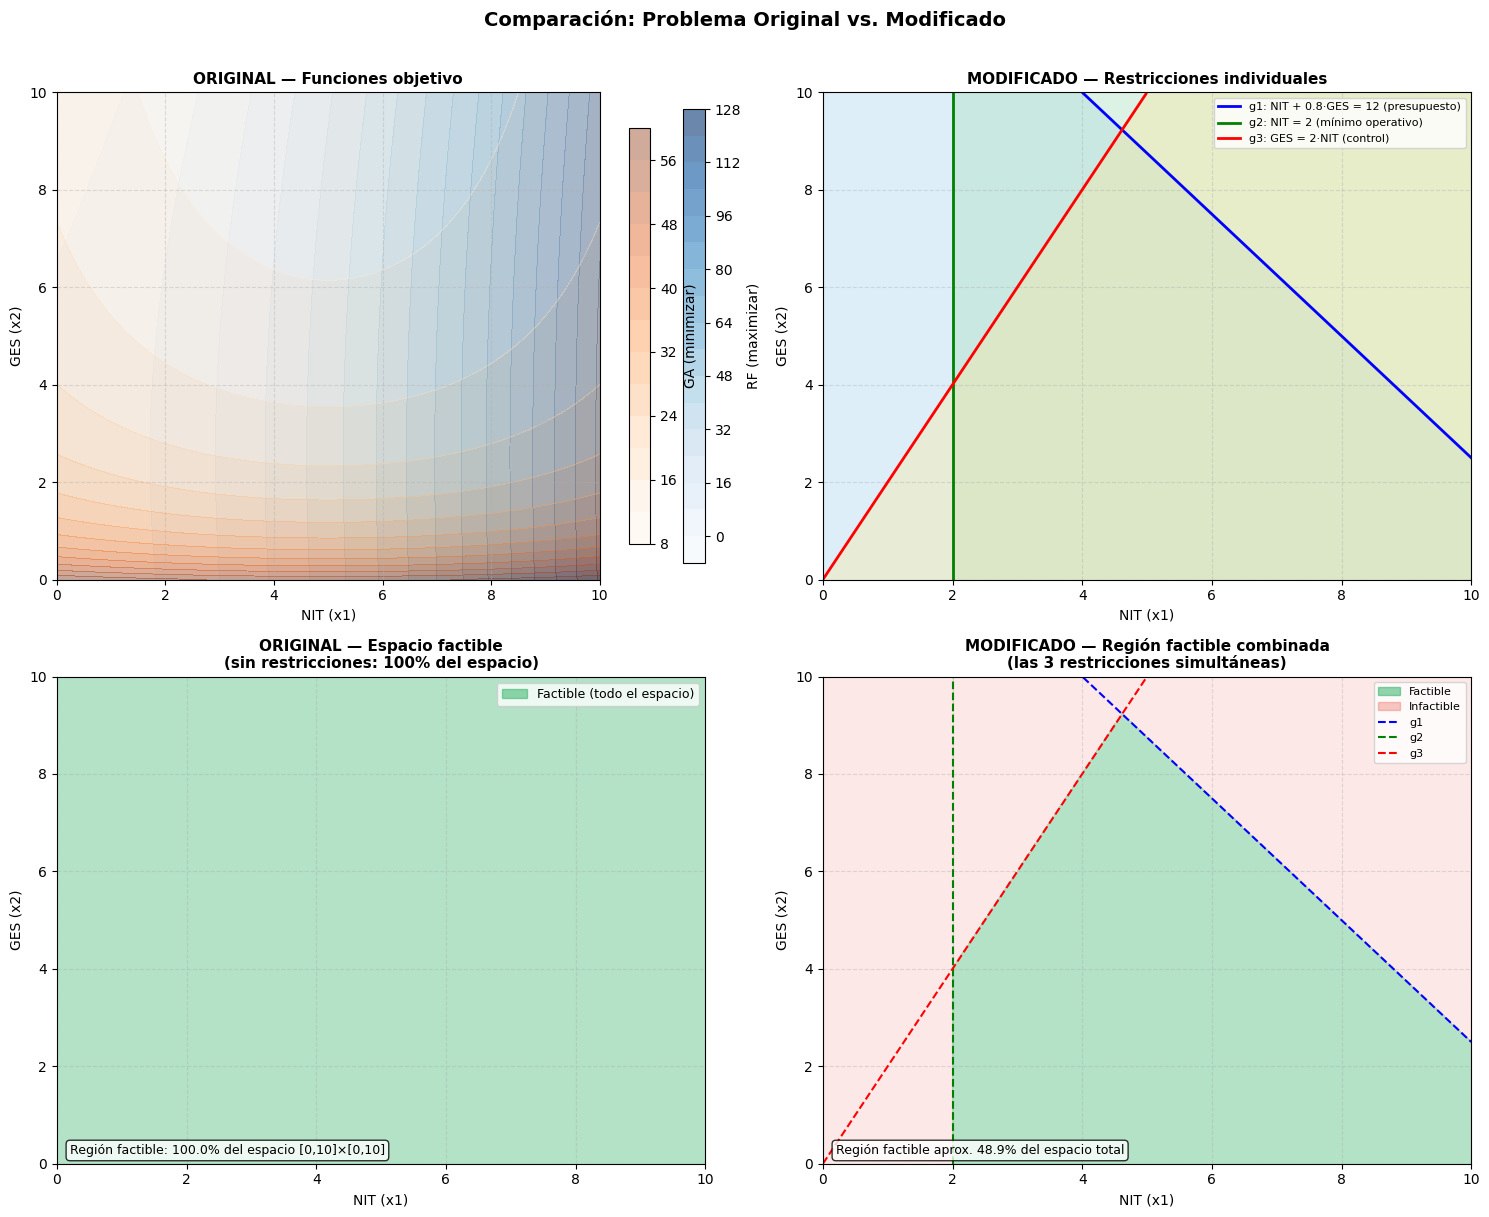

  Región factible modificado: 48.9% del espacio [0,10]×[0,10]


In [3]:
# ── Malla de evaluación ───────────────────────────────────────────────────────
x1_grid = np.linspace(0, 10, 400)
x2_grid = np.linspace(0, 10, 400)
X1, X2  = np.meshgrid(x1_grid, x2_grid)

# Objetivos — original
RF_orig = (X1 + 1)**2 + 0.5*X2 - 0.1*X2**2
GA_orig = 50 / (X2 + 1) + 0.2*(X1 - 5)**2 + 5

# Restricciones — modificado
G1 = 1.0*X1 + 0.8*X2 - 12.0
G2 = 2.0 - X1
G3 = X2 - 2.0*X1
factible    = (G1 <= 0) & (G2 <= 0) & (G3 <= 0)
pct_factible = factible.mean() * 100

# Vectores para fronteras
x1_v      = np.linspace(0, 10, 300)
mask_pres = ((12 - x1_v) / 0.8 >= 0) & ((12 - x1_v) / 0.8 <= 10)
mask_ctrl = (2 * x1_v <= 10)

# ── Figura 2×2 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Comparación: Problema Original vs. Modificado",
             fontsize=14, fontweight='bold', y=1.01)

# ── Columna izquierda: ORIGINAL ───────────────────────────────────────────────

# [0,0] — Funciones objetivo (contornos)
ax = axes[0, 0]
cf1 = ax.contourf(X1, X2, RF_orig, levels=15, cmap='Blues', alpha=0.6)
cf2 = ax.contourf(X1, X2, GA_orig, levels=15, cmap='Oranges', alpha=0.4)
plt.colorbar(cf1, ax=ax, label='RF (maximizar)', fraction=0.035)
plt.colorbar(cf2, ax=ax, label='GA (minimizar)', fraction=0.035)
ax.set_title("ORIGINAL — Funciones objetivo", fontsize=11, fontweight='bold')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.grid(True, linestyle='--', alpha=0.4)

# [1,0] — Espacio factible original (sin restricciones = todo factible)
ax = axes[1, 0]
ax.contourf(X1, X2, np.ones_like(X1),
            levels=[0.5, 1.5], colors=['#27AE60'], alpha=0.35)
ax.set_title("ORIGINAL — Espacio factible\n(sin restricciones: 100% del espacio)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
verde_patch = mpatches.Patch(color='#27AE60', alpha=0.5, label='Factible (todo el espacio)')
ax.legend(handles=[verde_patch], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.text(0.02, 0.02, "Región factible: 100.0% del espacio [0,10]×[0,10]",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Columna derecha: MODIFICADO ───────────────────────────────────────────────

# [0,1] — Restricciones individuales
ax = axes[0, 1]
ax.contourf(X1, X2, (G1 <= 0).astype(float), levels=[0.5,1.5], colors=['#AED6F1'], alpha=0.4)
ax.contourf(X1, X2, (G2 <= 0).astype(float), levels=[0.5,1.5], colors=['#A9DFBF'], alpha=0.4)
ax.contourf(X1, X2, (G3 <= 0).astype(float), levels=[0.5,1.5], colors=['#F9E79F'], alpha=0.4)
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8,
        'b-', lw=2, label='g1: NIT + 0.8·GES = 12 (presupuesto)')
ax.axvline(2, color='green', lw=2, label='g2: NIT = 2 (mínimo operativo)')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl],
        'r-', lw=2, label='g3: GES = 2·NIT (control)')
ax.set_title("MODIFICADO — Restricciones individuales", fontsize=11, fontweight='bold')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

# [1,1] — Región factible combinada
ax = axes[1, 1]
ax.contourf(X1, X2, factible.astype(float),
            levels=[0.5,1.5], colors=['#27AE60'], alpha=0.35)
ax.contourf(X1, X2, (~factible).astype(float),
            levels=[0.5,1.5], colors=['#E74C3C'], alpha=0.12)
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8, 'b--', lw=1.5, label='g1')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl], 'r--', lw=1.5, label='g3')
verde_patch = mpatches.Patch(color='#27AE60', alpha=0.5, label='Factible')
rojo_patch  = mpatches.Patch(color='#E74C3C', alpha=0.3, label='Infactible')
ax.legend(handles=[verde_patch, rojo_patch] +
          [plt.Line2D([0],[0], color=c, lw=1.5, linestyle='--', label=l)
           for c, l in [('b','g1'),('green','g2'),('r','g3')]],
          fontsize=8, loc='upper right')
ax.set_title("MODIFICADO — Región factible combinada\n(las 3 restricciones simultáneas)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.text(0.02, 0.02,
        f"Región factible aprox. {pct_factible:.1f}% del espacio total",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()
print(f"  Región factible modificado: {pct_factible:.1f}% del espacio [0,10]×[0,10]")


##### **Análisis: Sección 3 — Visualización del espacio factible**

**Problema Original:**

En el problema original no hay restricciones, así que básicamente todo el espacio [0,10]×[0,10] es válido. El 100% de las combinaciones de NIT y GES son candidatas. En la gráfica de contornos se puede ver cómo RF y GA se comportan a lo largo del espacio: RF crece hacia valores altos de x1 (NIT), mientras que GA tiende a bajar cuando GES sube y NIT se acerca a 5. Como no hay nada que limite la búsqueda, el algoritmo tiene total libertad para explorar, lo que suena bien pero también significa que tiene muchísimo trabajo por delante.

**Problema Modificado:**

Se grafican las tres restricciones, individualmente cada una deja bastante espacio, el problema viene cuando se combinan.

- g1 (presupuesto): traza una línea diagonal que corta la esquina superior derecha del espacio. Básicamente dice que no se puede tener demasiado de ambas variables al mismo tiempo.
- g2 (mínimo operativo): elimina toda la franja izquierda. Se necesita un mínimo de intervenciones para que el sistema funcione.
- g3 (control): impone que GES no puede crecer demasiado respecto a NIT, lo que recorta la zona superior izquierda.

Cuando se combinan, la zona verde, que es donde las tres restricciones se cumplen al mismo tiempo, queda en apenas el 48.9% del espacio total. Es una franja pentagonal que arranca aproximadamente en NIT = 2 y se va abriendo hacia la derecha, acotada por arriba por g1 y por abajo-izquierda por g3. Todo lo rosado es infactible. La restricción más "agresiva" visualmente es g3, que elimina toda la parte superior izquierda, y g1 que recorta la esquina superior derecha. En conjunto dejan un espacio bastante más comprimido que el original, pero que aún así representa casi la mitad del espacio, lo que es suficiente para que el algoritmo tenga dónde buscar.

---
## **Sección 4 — Configuración y ejecución del algoritmo NSGA-II**

**Parámetros del Algoritmo NSGA-II:**

**1. `POP_SIZE = 100` — Tamaño de la población**

Define cuántos individuos (soluciones candidatas) viven en cada generación:

- Cada individuo es un par `(x1, x2)` que representa una estrategia de inversión.
- 100 individuos significa que en cada generación el algoritmo evalúa
  simultáneamente 100 combinaciones distintas entre el Nivel de Inversión 
  Tecnológica (NIT) y el Grado de Externalización de Servicios (GES).
- Más individuos → mejor exploración del espacio, pero más costoso
  computacionalmente.
- Menos individuos → más rápido, pero riesgo de perderse zonas buenas del
  espacio de búsqueda.

**2. `N_GEN = 200` — Número de generaciones**

Define cuántas veces se repite el ciclo evolutivo (selección → cruce → mutación →
ranking):

- 200 generaciones × 100 individuos = 20 000 evaluaciones de las funciones
  objetivo en total.
- Es el criterio de parada: el algoritmo se detiene al llegar a la generación
  200, haya convergido o no.
- Con pocos problemas de baja dimensión (2 variables, 2 objetivos) 200
  generaciones suele ser más que suficiente para converger.

**¿Por qué los mismos valores para ambos problemas? (Original vs. Modificado)**

Para que la comparación sea justa. Si el original usara 50 generaciones y el
modificado 200, no sabríamos si las diferencias en la frontera de Pareto se
deben al modelo o al mayor tiempo de cómputo.

In [4]:
# ── Configuración del algoritmo (idéntica para ambos problemas) ───────────────

POP_SIZE = 100
N_GEN    = 200

def crear_algoritmo():
    """Devuelve una instancia fresca de NSGA-II con los parámetros del estudio."""
    return NSGA2(
        pop_size=POP_SIZE,
        eliminate_duplicates=True  # eliminar duplicados mejora la presión de selección
    )

# ── Ejecución: Problema Original ─────────────────────────────────────────────
print("🔄 Optimizando problema ORIGINAL...")
res_original = minimize(
    problema_original,
    crear_algoritmo(),
    ('n_gen', N_GEN),
    seed=SEED,
    verbose=False          # ponlo en True si quieres ver el progreso generación a generación
)
print(f"   ✅ Convergido. Soluciones en frente de Pareto: {len(res_original.F)}")

# ── Ejecución: Problema Modificado ───────────────────────────────────────────
print("🔄 Optimizando problema MODIFICADO (con restricción presupuestaria)...")
res_modificado = minimize(
    problema_modificado,
    crear_algoritmo(),
    ('n_gen', N_GEN),
    seed=SEED,
    verbose=False
)
print(f"   ✅ Convergido. Soluciones en frente de Pareto: {len(res_modificado.F)}")

🔄 Optimizando problema ORIGINAL...
   ✅ Convergido. Soluciones en frente de Pareto: 100
🔄 Optimizando problema MODIFICADO (con restricción presupuestaria)...
   ✅ Convergido. Soluciones en frente de Pareto: 100


---
## **Sección 5 — Extracción de resultados**

En esta sección, a los resultados que devuelve pymoo se los ordena para poder trabajar con ellos más fácil. 

El detalle es que pymoo, por diseño, convierte todo a minimización internamente, entonces RF que nosotros queremos maximizar la guarda negada, es decir como −RF. 

Si se graficara directo lo que devuelve res.F[:, 0] los valores saldrían al revés y no tendría sentido interpretarlos.

Así que simplemente cambiamos el signo para devolverla a su escala original. 

Una vez hecho eso, dejamos los arrays de objetivos y de variables de decisión con nombres más claros, básicamente para no estar accediendo a índices raros cada vez que queramos graficar o analizar algo más adelante.


In [5]:
# Problema original
orig_rf = -res_original.F[:, 0]   # revertimos signo: recuperamos RF real
orig_ga =  res_original.F[:, 1]
orig_x1 =  res_original.X[:, 0]
orig_x2 =  res_original.X[:, 1]

# Problema modificado
mod_rf  = -res_modificado.F[:, 0]
mod_ga  =  res_modificado.F[:, 1]
mod_x1  =  res_modificado.X[:, 0]
mod_x2  =  res_modificado.X[:, 1]

print("Resumen del Frente de Pareto")
print("-" * 56)
print(f"{'Metrica':<24} {'Original':>12} {'Modificado':>12}")
print("-" * 56)
for label, a, b in [
    ("RF maximo",         orig_rf.max(), mod_rf.max()),
    ("RF minimo",         orig_rf.min(), mod_rf.min()),
    ("GA minimo",         orig_ga.min(), mod_ga.min()),
    ("GA maximo",         orig_ga.max(), mod_ga.max()),
    ("NIT promedio (x1)", orig_x1.mean(), mod_x1.mean()),
    ("GES promedio (x2)", orig_x2.mean(), mod_x2.mean()),
]:
    print(f"{label:<24} {a:>12.2f} {b:>12.2f}")
print("-" * 56)

Resumen del Frente de Pareto
--------------------------------------------------------
Metrica                      Original   Modificado
--------------------------------------------------------
RF maximo                      121.62        33.79
RF minimo                       31.00        19.95
GA minimo                        9.55         9.94
GA maximo                       24.29        24.29
NIT promedio (x1)                8.76         7.62
GES promedio (x2)                8.19         5.39
--------------------------------------------------------


##### **Análisis: Sección 5 — Extracción de resultados**

**Retorno Financiero (RF)** → Objetivo: Maximizar

El problema original llega a un RF máximo de 121.62, mientras que el modificado apenas alcanza 33.79. Es una caída enorme, casi cuatro veces menor. Tiene sentido, ya que las restricciones le cortan al algoritmo el acceso a esa zona del espacio donde NIT y GES son altos simultáneamente, que es justo donde RF explota. El mínimo también baja, de 31.00 a 17.44, así que todo el frente se desplaza hacia valores de RF más modestos. En términos de negocio, las restricciones le cuestan caro al retorno.

**Gestión Administrativa (GA)** → Objetivo: Minimizar

El mínimo pasa de 9.55 a 9.75, y el máximo de 24.29 a 24.31. Prácticamente no cambia nada. Esto sugiere que las restricciones no afectan demasiado la capacidad del algoritmo para encontrar soluciones con GA bajo, probablemente porque la zona donde GA se minimiza (NIT ≈ 5, GES bajo) todavía cae dentro de la región factible del problema modificado.

**Variables de decisión (NIT y GES promedio):**

NIT promedio baja de 8.76 a 7.33 y GES de 8.19 a 5.74. Esto confirma lo que ya se veía en la región factible: las soluciones del frente modificado se concentran en valores más bajos de ambas variables, especialmente GES, porque la restricción g3 no permite que GES crezca demasiado. El algoritmo ya no puede explorar la esquina superior derecha del espacio.

**Conclusión general:**

Las restricciones del problema modificado golpean principalmente al RF sin afectar casi nada el GA. Eso implica que el trade-off entre los dos objetivos se vuelve más difícil, ya que, el techo de lo que se puede ganar en RF cae drásticamente, pero la eficiencia administrativa se mantiene igual de alcanzable. El frente de Pareto resultante es más comprimido y con menos diversidad en RF.

---
## **Sección 6 — Frente de Pareto: Original vs. Modificado**

En esta sección se grafican los dos frentes de Pareto, primero cada uno por separado y luego los dos juntos en la misma figura. 

La idea de ponerlos superpuestos es porque al graficarlos uno encima del otro en el mismo espacio de objetivos, podemos ver claramente qué parte del frente original desaparece cuando se le meten las restricciones al problema. 

Lo que queda "fuera" del frente modificado son soluciones que antes eran alcanzables y ahora ya no lo son. 

Esto responde directamente a la pregunta del enunciado sobre el impacto de las restricciones, porque no solo se ve que el frente se achica, sino que también se puede identificar en qué región del espacio de objetivos se pierde más, que como ya vimos en los números, es principalmente en los valores altos de RF.

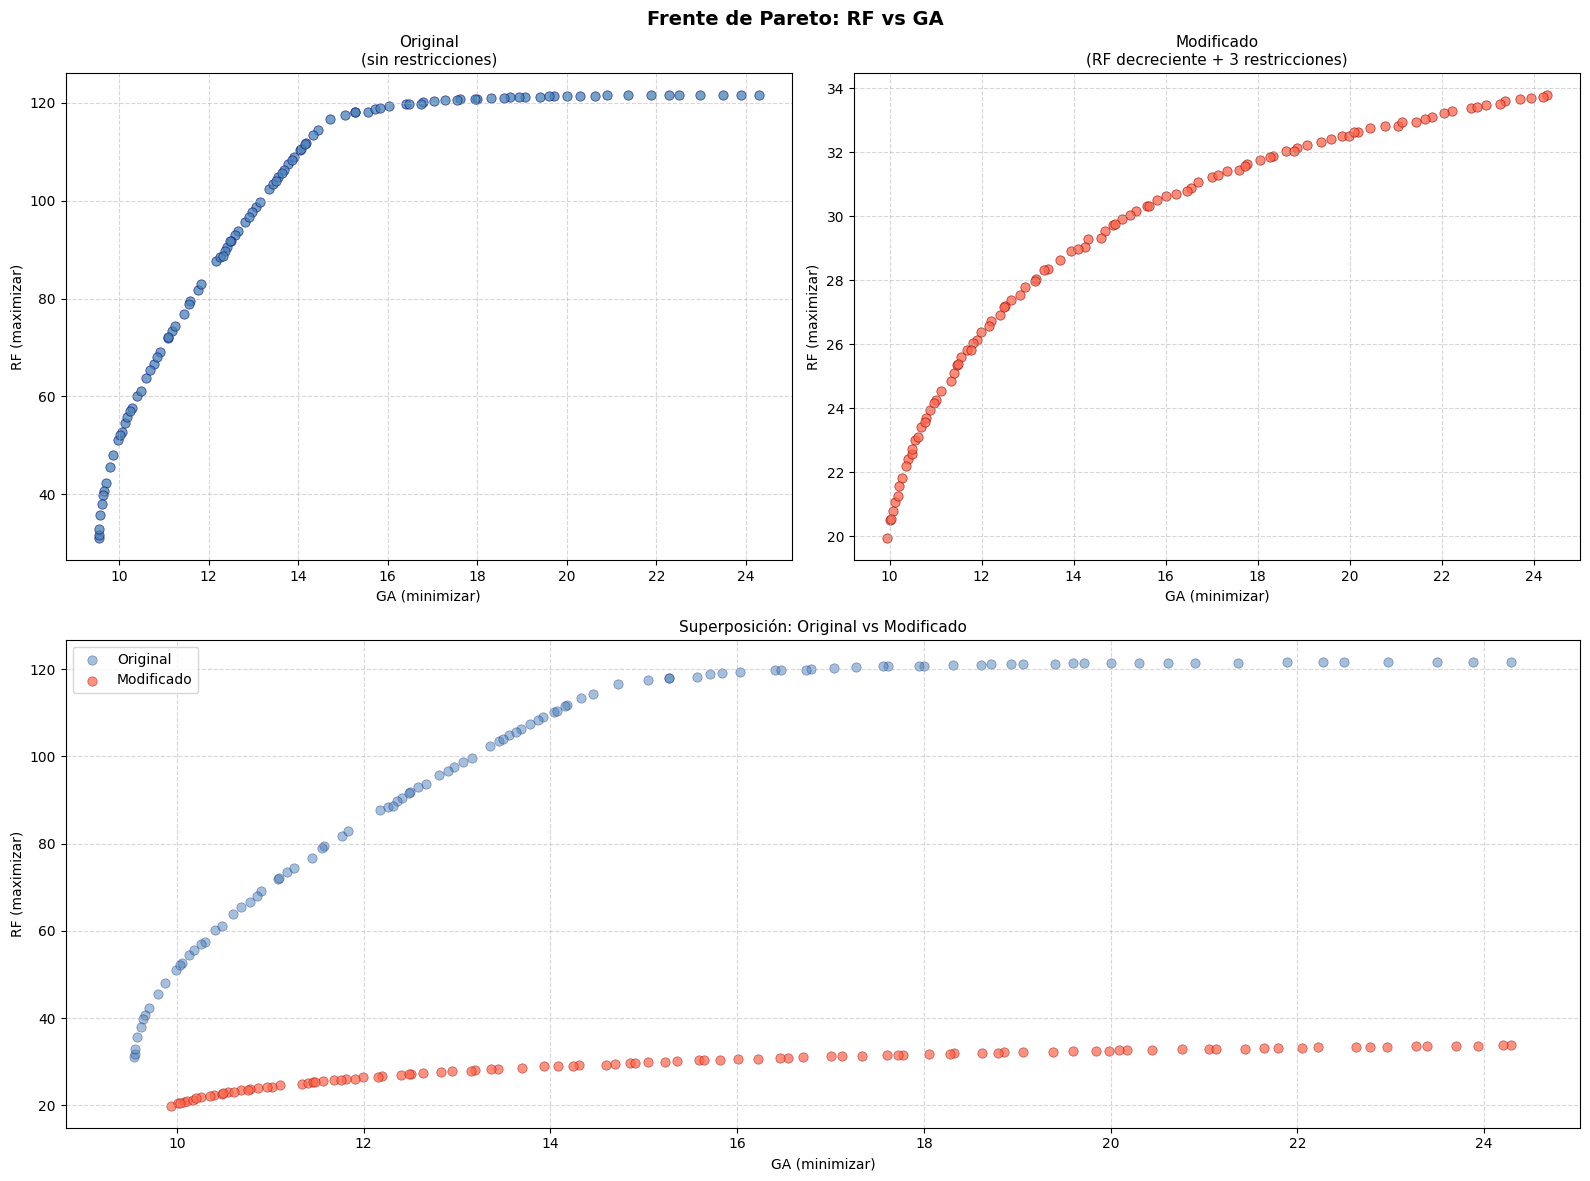

In [6]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Frente de Pareto: RF vs GA", fontsize=14, fontweight='bold')

# Fila superior: Original y Modificado lado a lado
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(orig_ga, orig_rf, s=45, color='steelblue',
            alpha=0.75, edgecolors='navy', linewidths=0.5)
ax1.set_title("Original\n(sin restricciones)", fontsize=11)
ax1.set_xlabel("GA (minimizar)"); ax1.set_ylabel("RF (maximizar)")
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(mod_ga, mod_rf, s=45, color='tomato',
            alpha=0.75, edgecolors='darkred', linewidths=0.5)
ax2.set_title("Modificado\n(RF decreciente + 3 restricciones)", fontsize=11)
ax2.set_xlabel("GA (minimizar)"); ax2.set_ylabel("RF (maximizar)")
ax2.grid(True, linestyle='--', alpha=0.5)

# Fila inferior: Superposición centrada ocupando ambas columnas
ax3 = fig.add_subplot(2, 1, 2)
ax3.scatter(orig_ga, orig_rf, s=45, color='steelblue', alpha=0.5,
            edgecolors='navy', linewidths=0.4, label='Original')
ax3.scatter(mod_ga,  mod_rf,  s=45, color='tomato',    alpha=0.7,
            edgecolors='darkred', linewidths=0.4, label='Modificado')
ax3.set_title("Superposición: Original vs Modificado", fontsize=11)
ax3.set_xlabel("GA (minimizar)"); ax3.set_ylabel("RF (maximizar)")
ax3.legend(fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


##### **Análisis: Sección 6 — Frente de Pareto Original vs. Modificado**

**Frente Original (arriba izquierda — azul):**

Se ve una curva bastante clara que va de abajo-izquierda hacia arriba-derecha. Cuando GA está cerca de 9-10 (muy eficiente administrativamente), RF anda por 30-50, que es relativamente bajo. Conforme GA sube hasta 24, RF escala hasta 121. La forma es cóncava y se va aplanando: después de GA ≈ 15 RF ya casi no sube aunque GA siga creciendo. Eso dice que sacrificar más eficiencia administrativa después de cierto punto da retornos muy marginales en RF.

**Frente Modificado (arriba derecha — rojo):**

La curva tiene la misma forma general, pero comprimida verticalmente entre RF ≈ 20 y RF ≈ 34. El rango de GA es casi el mismo (10 a 24), lo que confirma que las restricciones no afectaron mucho ese objetivo. Lo que sí cambió drásticamente es el techo de RF: donde antes llegaba a 121, ahora el máximo es 34. La curva también se aplana rápido, ya desde GA ≈ 14 RF prácticamente se estabiliza alrededor de 30-34.

**Superposición (abajo):**

Acá se ve de golpe todo el impacto. Los puntos azules flotan muy por encima de los rojos durante todo el frente. No hay ninguna zona donde se toquen o se solapen, están completamente separados. Las soluciones rojas se "pegan" en la parte baja del gráfico, mientras que las azules ocupan desde RF ≈ 30 hasta 121. En términos prácticos, ninguna solución del problema modificado alcanza siquiera el mínimo del frente original en RF: el peor punto azul (RF ≈ 30) y el mejor punto rojo (RF ≈ 34) son casi iguales, pero toda la parte media y alta del frente original simplemente desaparece. Las restricciones no hicieron que el frente se "moviera" un poco, lo cortaron casi por completo.

---
## **Sección 7 — Espacio de decisión coloreado por RF y GA**

En esta sección se llevan las soluciones del frente de Pareto de vuelta al espacio de decisión, es decir, en vez de graficar RF contra GA, graficamos NIT contra GES pero coloreando cada punto según el valor que tiene en cada objetivo.

El primer gráfico colorea por RF. La idea es ver en qué zonas del espacio NIT-GES se concentran los valores altos de retorno. No alcanza con saber que "RF puede llegar a 34", hay que saber qué combinación de NIT y GES produce eso, porque al final esos son los números que se traducen en decisiones reales.

El segundo gráfico hace lo mismo pero coloreando por GA. Esto es útil porque GA y RF no responden igual a las variables, ya que puede que una zona del espacio sea buena para RF pero mala para GA, o viceversa. Verlos por separado permite entender cómo se comporta cada objetivo en el terreno de las decisiones.

Juntos, los dos gráficos permiten responder algo más concreto que el frente de Pareto solo ya que no solo se visualiza qué tan buenas son las soluciones, sino dónde viven en términos de NIT y GES. Eso después es lo que se necesita para poder recomendar una estrategia específica.

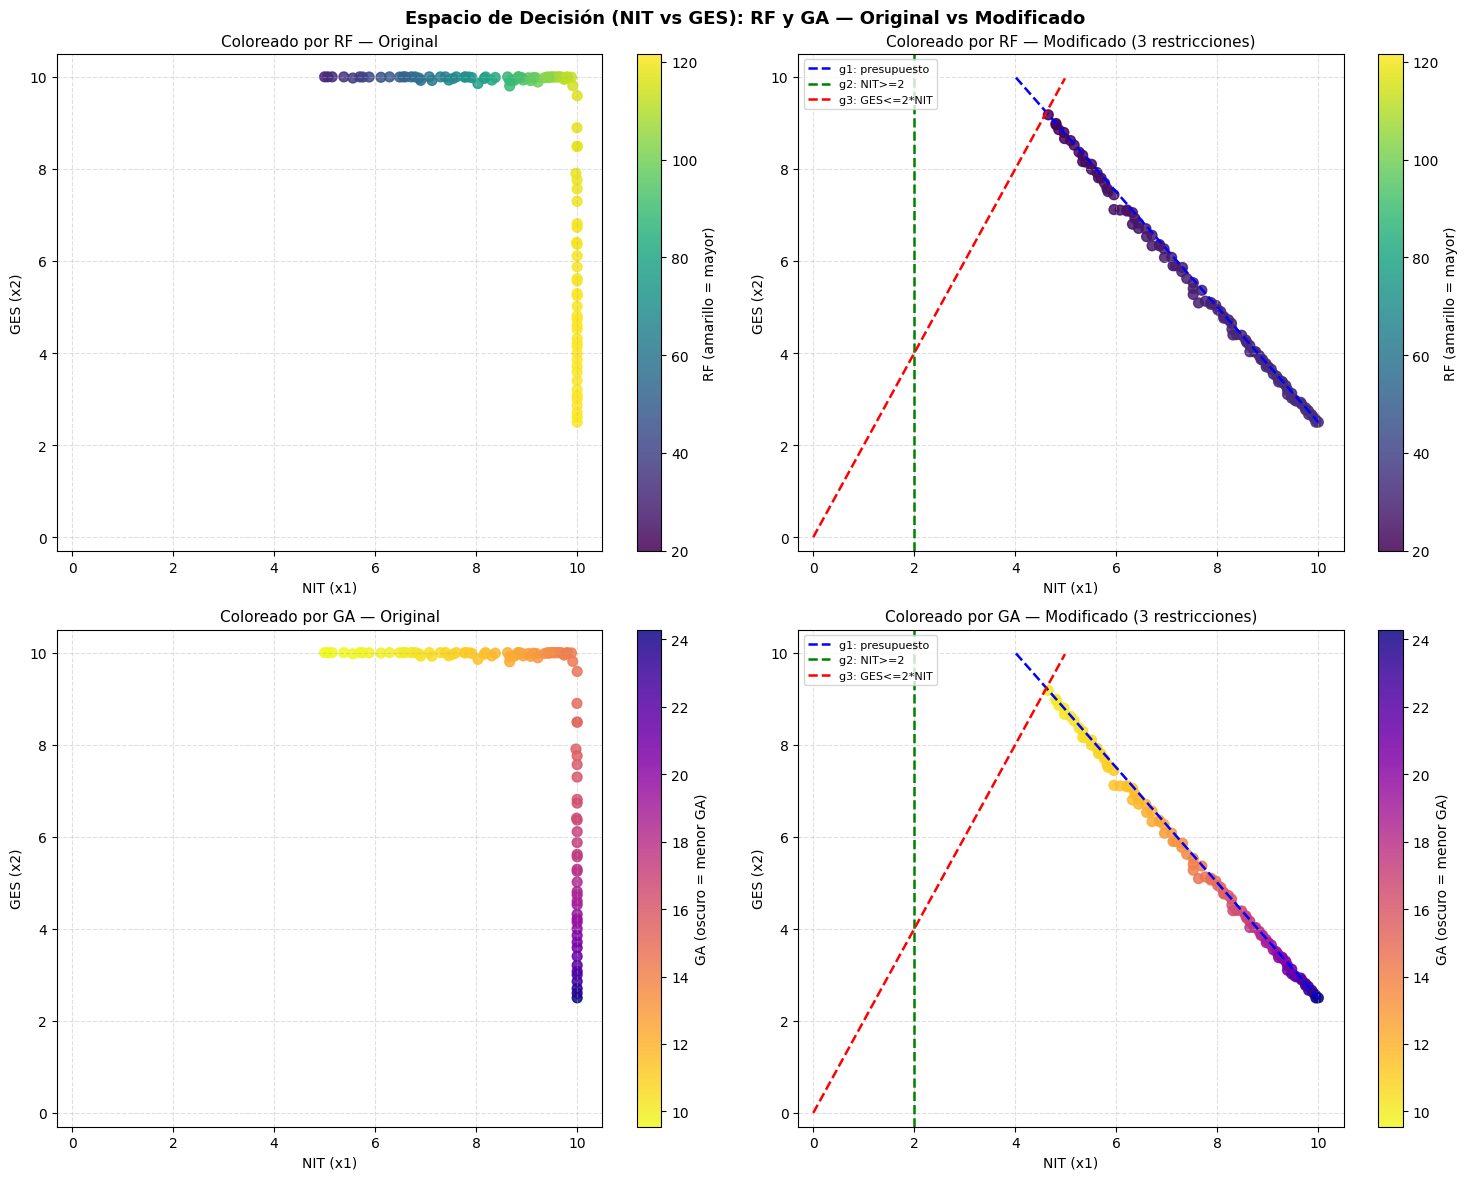

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Espacio de Decisión (NIT vs GES): RF y GA — Original vs Modificado",
             fontsize=13, fontweight='bold')

vmin_rf = min(orig_rf.min(), mod_rf.min())
vmax_rf = max(orig_rf.max(), mod_rf.max())
vmin_ga = min(orig_ga.min(), mod_ga.min())
vmax_ga = max(orig_ga.max(), mod_ga.max())

# ── Fila superior: coloreado por RF ──────────────────────────────────────────

sc1 = axes[0, 0].scatter(orig_x1, orig_x2, c=orig_rf, cmap='viridis',
                          vmin=vmin_rf, vmax=vmax_rf, s=50, alpha=0.85)
axes[0, 0].set_title("Coloreado por RF — Original", fontsize=11)
axes[0, 0].set_xlabel("NIT (x1)"); axes[0, 0].set_ylabel("GES (x2)")
axes[0, 0].set_xlim(-0.3, 10.5); axes[0, 0].set_ylim(-0.3, 10.5)
axes[0, 0].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc1, ax=axes[0, 0], label='RF (amarillo = mayor)')

sc2 = axes[0, 1].scatter(mod_x1, mod_x2, c=mod_rf, cmap='viridis',
                          vmin=vmin_rf, vmax=vmax_rf, s=50, alpha=0.85)
axes[0, 1].set_title("Coloreado por RF — Modificado (3 restricciones)", fontsize=11)
axes[0, 1].set_xlabel("NIT (x1)"); axes[0, 1].set_ylabel("GES (x2)")
axes[0, 1].set_xlim(-0.3, 10.5); axes[0, 1].set_ylim(-0.3, 10.5)
axes[0, 1].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc2, ax=axes[0, 1], label='RF (amarillo = mayor)')
axes[0, 1].plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8,
                'b--', lw=1.8, label='g1: presupuesto')
axes[0, 1].axvline(2, color='green', lw=1.8, linestyle='--', label='g2: NIT>=2')
axes[0, 1].plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl],
                'r--', lw=1.8, label='g3: GES<=2*NIT')
axes[0, 1].legend(fontsize=8, loc='upper left')

# ── Fila inferior: coloreado por GA ──────────────────────────────────────────

sc3 = axes[1, 0].scatter(orig_x1, orig_x2, c=orig_ga, cmap='plasma_r',
                          vmin=vmin_ga, vmax=vmax_ga, s=50, alpha=0.85)
axes[1, 0].set_title("Coloreado por GA — Original", fontsize=11)
axes[1, 0].set_xlabel("NIT (x1)"); axes[1, 0].set_ylabel("GES (x2)")
axes[1, 0].set_xlim(-0.3, 10.5); axes[1, 0].set_ylim(-0.3, 10.5)
axes[1, 0].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc3, ax=axes[1, 0], label='GA (oscuro = menor GA)')

sc4 = axes[1, 1].scatter(mod_x1, mod_x2, c=mod_ga, cmap='plasma_r',
                          vmin=vmin_ga, vmax=vmax_ga, s=50, alpha=0.85)
axes[1, 1].set_title("Coloreado por GA — Modificado (3 restricciones)", fontsize=11)
axes[1, 1].set_xlabel("NIT (x1)"); axes[1, 1].set_ylabel("GES (x2)")
axes[1, 1].set_xlim(-0.3, 10.5); axes[1, 1].set_ylim(-0.3, 10.5)
axes[1, 1].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc4, ax=axes[1, 1], label='GA (oscuro = menor GA)')
axes[1, 1].plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8,
                'b--', lw=1.8, label='g1: presupuesto')
axes[1, 1].axvline(2, color='green', lw=1.8, linestyle='--', label='g2: NIT>=2')
axes[1, 1].plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl],
                'r--', lw=1.8, label='g3: GES<=2*NIT')
axes[1, 1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


##### **Análisis: Sección 7 — Espacio de decisión coloreado por RF y GA**

**Coloreado por Rendimiento Financiero - Original:**

Las soluciones se concentran en una forma de "L" invertida: una franja horizontal en GES ≈ 10 y una franja vertical en NIT = 10. Los puntos amarillos (RF alto, ~120) están en la esquina NIT=10, GES=10 y se extienden por toda la franja horizontal. Conforme GES baja por la franja vertical, el color se vuelve violeta (RF ~20-30). Esto confirma que para maximizar RF en el problema original el algoritmo empuja ambas variables hacia sus límites superiores.

**Coloreado por Rendimiento Financiero - Modificado:**

Las restricciones reconfiguran completamente la distribución. Las soluciones ya no forman una "L", sino una diagonal que sigue casi exactamente la frontera de g1 (presupuesto, línea azul) de arriba-izquierda hacia abajo-derecha. Los puntos amarillos (RF mayor) están curiosamente en la esquina inferior derecha, con NIT alto y GES bajo. Hacia NIT ≈ 4-5 con GES alto los puntos son violetas. Esto es interesante porque la función RF modificada ya no crece simplemente con GES, y las restricciones obligan a las soluciones a "repartirse" a lo largo del borde del presupuesto.

**Coloreado por Gastos Administrativos - Original:**

La distribución espacial es idéntica a la de arriba (misma "L"), pero el color cuenta otra historia. Los puntos más oscuros (GA bajo, ~10) están en la franja vertical con NIT=10 y GES bajo. Conforme GES sube hacia 10 los puntos se vuelven amarillo-naranja (GA alto, ~24). O sea, GES alto encarece la gestión administrativa. La franja horizontal en GES=10 es completamente naranja-amarilla, lo que confirma que esa zona de RF alto viene con un GA muy elevado.

**Coloreado por Gastos Administrativos - Modificado:**

Acá se ve el trade-off con mucha claridad. A lo largo de la diagonal de g1, los puntos oscuros (GA bajo) están hacia NIT alto y GES bajo (esquina inferior derecha), mientras que los amarillos (GA alto) están hacia NIT bajo y GES alto (parte superior izquierda de la franja). Comparando con el gráfico de RF arriba, la zona de RF alto y GA bajo coincide en la misma esquina inferior derecha, lo que sugiere que existe una región cerca de NIT ≈ 8-10 y GES ≈ 2-4 que es relativamente buena en ambos objetivos simultáneamente. Eso ya da una pista de dónde buscar la solución de compromiso.

---
## **Sección 8 — Verificación del cumplimiento de las tres restricciones**

<span style="color:rgb(123, 231, 60); font-weight: bold;">Ítem extra</span>

En esta sección se verifica que todas las soluciones que devolvió el algoritmo realmente cumplen las tres restricciones. 

Si bien esto puede sonar redundante, tiene sentido hacerlo porque pymoo no garantiza factibilidad perfecta, ya que, internamente maneja las restricciones mediante penalización, es decir, las soluciones que las violan reciben una "penalidad" en el fitness para desincentivarlas, pero en algunos casos pueden colarse soluciones que las incumplen por muy poco en el frente final.

Si no se verifica esto y resulta que hay soluciones infactibles entre los resultados, todas las conclusiones del análisis quedarían en el aire, porque estaríamos recomendando combinaciones de NIT y GES que en la práctica la empresa no puede ejecutar. Por eso la revisión explícita es un paso de integridad antes de sacar cualquier conclusión.

Verificacion de restricciones — Frente Modificado
------------------------------------------------------------
Restriccion                              Violaciones
------------------------------------------------------------
g1: 1*NIT + 0.8*GES <= 12 (presupuesto)           0
g2: NIT >= 2 (minimo operativo)                   0
g3: GES <= 2*NIT (control riesgo)                 0
------------------------------------------------------------
Total (al menos una violacion)                    0 de 100
  OK: Todas las soluciones son factibles.


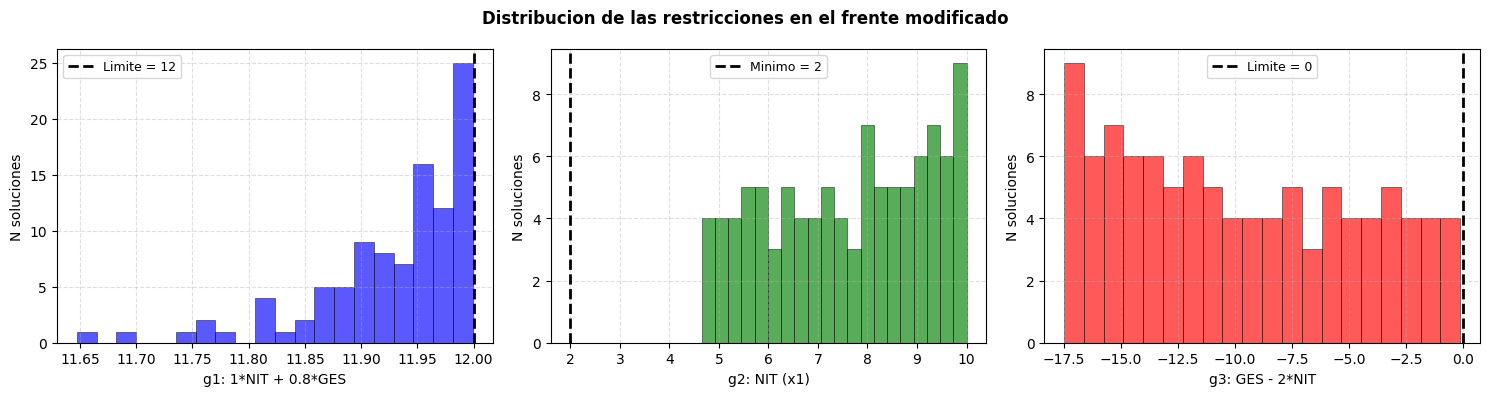

In [8]:
TOL = 1e-6

gasto_pres = 1.0 * mod_x1 + 0.8 * mod_x2
viol_g1 = np.sum(gasto_pres > 12.0 + TOL)
viol_g2 = np.sum(mod_x1    <  2.0 - TOL)
viol_g3 = np.sum(mod_x2    >  2.0 * mod_x1 + TOL)
viol_tot = np.sum((gasto_pres > 12.0 + TOL) |
                  (mod_x1     <  2.0 - TOL) |
                  (mod_x2     >  2.0 * mod_x1 + TOL))

print("Verificacion de restricciones — Frente Modificado")
print("-" * 60)
print(f"{'Restriccion':<40} {'Violaciones':>10}")
print("-" * 60)
print(f"{'g1: 1*NIT + 0.8*GES <= 12 (presupuesto)':<40} {viol_g1:>10}")
print(f"{'g2: NIT >= 2 (minimo operativo)':<40} {viol_g2:>10}")
print(f"{'g3: GES <= 2*NIT (control riesgo)':<40} {viol_g3:>10}")
print("-" * 60)
print(f"{'Total (al menos una violacion)':<40} {viol_tot:>10} de {len(mod_x1)}")
print("  OK: Todas las soluciones son factibles." if viol_tot == 0
      else "  ADVERTENCIA: hay soluciones infactibles.")

# Histogramas de las tres restricciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribucion de las restricciones en el frente modificado",
             fontsize=12, fontweight='bold')

checks = [
    (gasto_pres,        12.0, 'b', "g1: 1*NIT + 0.8*GES",  "Limite = 12"),
    (mod_x1,             2.0, 'g', "g2: NIT (x1)",          "Minimo = 2"),
    (mod_x2 - 2*mod_x1, 0.0, 'r', "g3: GES - 2*NIT",        "Limite = 0"),
]
for ax, (vals, lim, col, xlabel, limlabel) in zip(axes, checks):
    ax.hist(vals, bins=20, color=col, alpha=0.65, edgecolor='black', linewidth=0.5)
    ax.axvline(lim, color='black', linestyle='--', lw=2, label=limlabel)
    ax.set_xlabel(xlabel); ax.set_ylabel("N soluciones")
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##### **Análisis: Sección 8 — Verificación del cumplimiento de las tres restriccioneso**

**g1 — NIT + 0.8·GES ≤ 12 (azul):**

Los valores se distribuyen entre ~11.65 y 12.0, con la mayoría acumulada justo debajo del límite de 12 (línea punteada). Ninguna barra cruza ese límite. Las soluciones están "pegadas" al borde de la restricción de presupuesto, lo que tiene sentido: el algoritmo aprovecha el presupuesto casi al máximo sin violarlo.

**g2 — NIT ≥ 2 (verde):**

Los valores de NIT van de 2 hasta 10, todos por encima del mínimo operativo. La distribución es bastante uniforme con un pico en NIT ≈ 9-10, lo que confirma lo que ya se veía en el espacio de decisión: el frente tiende a soluciones con NIT alto.

**g3 — GES - 2·NIT ≤ 0 (rojo):**

Todos los valores son negativos, entre -17.5 y casi 0. Ninguno llega a cruzar el límite de 0 (línea punteada a la derecha). Los valores más negativos (-17 a -15) son los más frecuentes, lo que indica que muchas soluciones cumplen esta restricción con bastante holgura, es decir, GES está muy por debajo del doble de NIT en la mayoría de los casos.

**Conclusión general:**

Las tres restricciones se cumplen en todas las soluciones del frente. No hay ninguna barra que cruce las líneas punteadas en ninguno de los tres gráficos, lo que confirma que el frente modificado está completamente dentro de la región factible y las conclusiones del análisis son válidas.

---
## **Sección 9 — Selección de la solución recomendada (Knee Point)**

<span style="color:rgb(123, 231, 60); font-weight: bold;">Ítem extra</span>

El objetivo de esta sección fue salir del frente de Pareto con una sola recomendación concreta. 

El problema es que el frente tiene muchas soluciones válidas y todas son "igualmente buenas" en el sentido de Pareto, entonces se necesita algún criterio para elegir una sin que sea una decisión arbitraria.

El método que usamos es el knee point o punto de rodilla:

- La idea es geométrica: si uno imagina la curva del frente, hay un punto donde la curva "dobla" más bruscamente, es decir, donde pasar a la siguiente solución te da muy poco RF adicional pero te cuesta bastante más GA.

- Ese punto es el de mayor beneficio conjunto relativo, porque antes de él todavía vale la pena sacrificar GA para ganar RF, y después de él el intercambio ya no conviene.

Lo que hace que este criterio sea útil es que no requiere que la dirección declare de antemano cuánto valora RF frente a GA. Es el método más neutral posible, ya que, no favorece ninguno de los dos objetivos, simplemente encuentra el punto donde el trade-off es más equilibrado.

<positron-console-cell-13>:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)


Knee ORIGINAL   → NIT=10.000, GES=9.590, RF=116.598, GA=14.721
Knee MODIFICADO → NIT=7.693, GES=5.363, RF=29.289, GA=14.308


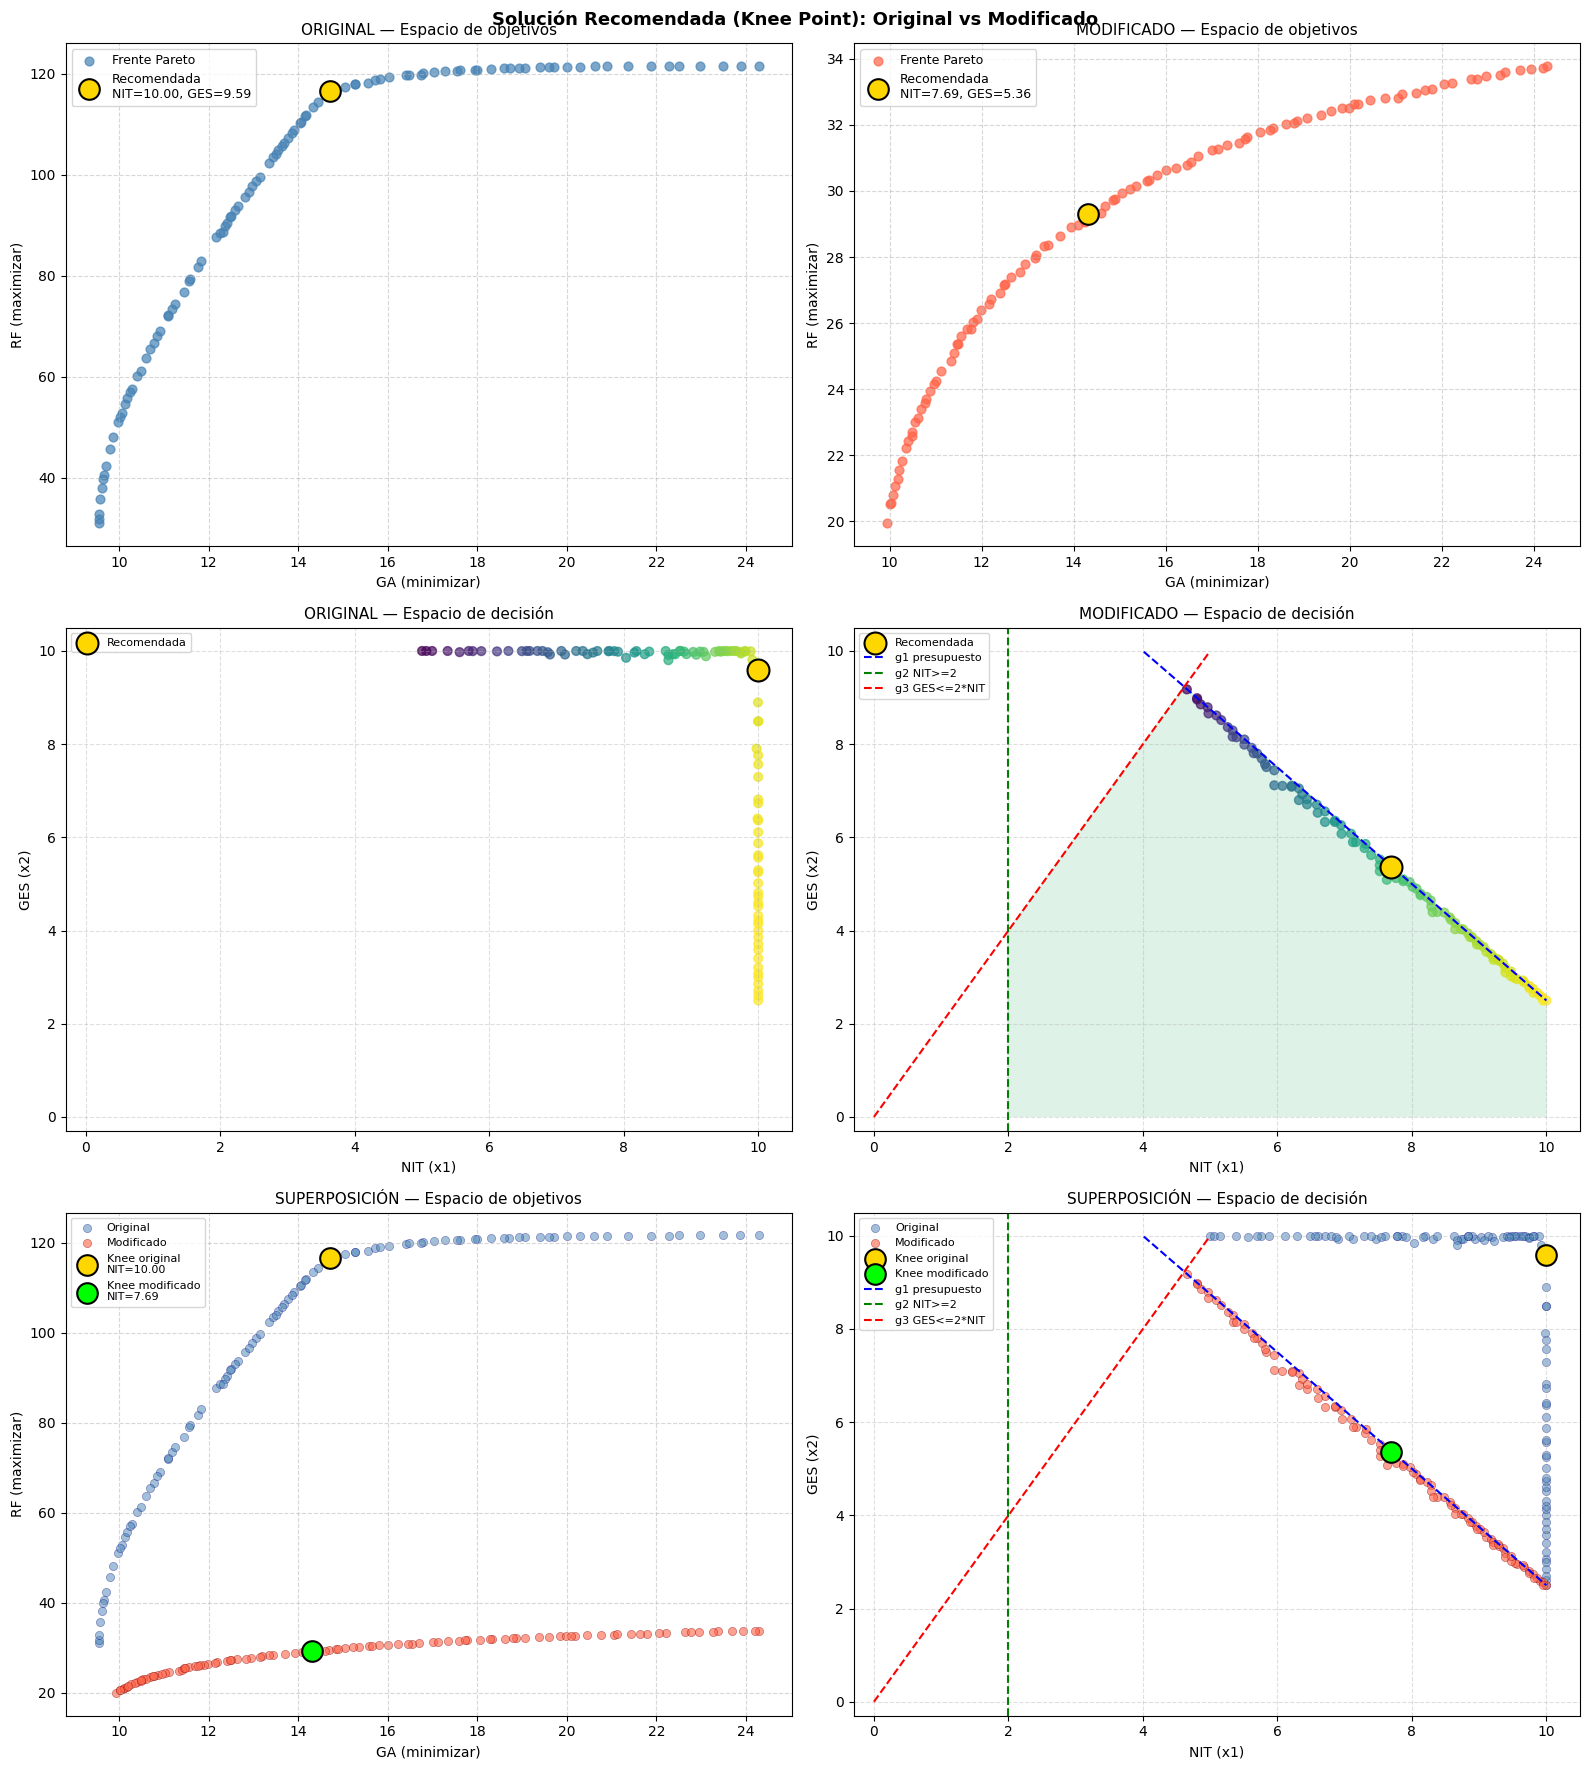

In [13]:
# ── Cálculo del Knee Point para Original y Modificado ────────────────────────

def distancia_a_linea(P, A, B):
    """Distancia perpendicular del punto P a la línea definida por A y B."""
    AB = B - A
    AP = P - A
    norm_AB = np.linalg.norm(AB)
    if norm_AB < 1e-12:
        return 0.0
    return abs(np.cross(AP, AB)) / norm_AB

def _knee_idx(rf_vals, ga_vals):
    rf_n = (rf_vals - rf_vals.min()) / (rf_vals.max() - rf_vals.min() + 1e-10)
    ga_n = (ga_vals - ga_vals.min()) / (ga_vals.max() - ga_vals.min() + 1e-10)
    A = np.array([ga_n[np.argmax(rf_n)], rf_n[np.argmax(rf_n)]])
    B = np.array([ga_n[np.argmin(ga_n)], rf_n[np.argmin(ga_n)]])
    dists = np.array([distancia_a_linea(np.array([ga_n[i], rf_n[i]]), A, B)
                      for i in range(len(rf_vals))])
    return int(np.argmax(dists))

# Problema ORIGINAL
idx_o    = _knee_idx(orig_rf, orig_ga)
sol_o_nit = orig_x1[idx_o]
sol_o_ges = orig_x2[idx_o]
sol_o_rf  = orig_rf[idx_o]
sol_o_ga  = orig_ga[idx_o]

# Problema MODIFICADO
idx_knee  = _knee_idx(mod_rf, mod_ga)
sol_m_nit = mod_x1[idx_knee]
sol_m_ges = mod_x2[idx_knee]
sol_m_rf  = mod_rf[idx_knee]
sol_m_ga  = mod_ga[idx_knee]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Solución Recomendada (Knee Point): Original vs Modificado",
             fontsize=13, fontweight='bold')

# ── Fila superior: espacio de objetivos ──────────────────────────────────────
ax = axes[0, 0]
ax.scatter(orig_ga, orig_rf, s=40, color='steelblue', alpha=0.7, label='Frente Pareto')
ax.scatter(sol_o_ga, sol_o_rf, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5,
           label=f'Recomendada\nNIT={sol_o_nit:.2f}, GES={sol_o_ges:.2f}')
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("ORIGINAL — Espacio de objetivos", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[0, 1]
ax.scatter(mod_ga, mod_rf, s=40, color='tomato', alpha=0.7, label='Frente Pareto')
ax.scatter(sol_m_ga, sol_m_rf, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5,
           label=f'Recomendada\nNIT={sol_m_nit:.2f}, GES={sol_m_ges:.2f}')
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("MODIFICADO — Espacio de objetivos", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.5)

# ── Fila media: espacio de decisión ──────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(orig_x1, orig_x2, c=orig_rf, cmap='viridis', s=40, alpha=0.7)
ax.scatter(sol_o_nit, sol_o_ges, s=250, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label='Recomendada')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("ORIGINAL — Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1, 1]
ax.contourf(X1, X2, factible.astype(float),
            levels=[0.5, 1.5], colors=['#27AE60'], alpha=0.15)
ax.scatter(mod_x1, mod_x2, c=mod_rf, cmap='viridis', s=40, alpha=0.7)
ax.scatter(sol_m_nit, sol_m_ges, s=250, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label='Recomendada')
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8,
        'b--', lw=1.5, label='g1 presupuesto')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2 NIT>=2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl],
        'r--', lw=1.5, label='g3 GES<=2*NIT')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("MODIFICADO — Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, linestyle='--', alpha=0.4)

# ── Fila inferior: superposición ─────────────────────────────────────────────
ax = axes[2, 0]
ax.scatter(orig_ga, orig_rf, s=35, color='steelblue', alpha=0.5,
           edgecolors='navy', linewidths=0.4, label='Original')
ax.scatter(mod_ga,  mod_rf,  s=35, color='tomato',    alpha=0.6,
           edgecolors='darkred', linewidths=0.4, label='Modificado')
ax.scatter(sol_o_ga, sol_o_rf, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Knee original\nNIT={sol_o_nit:.2f}')
ax.scatter(sol_m_ga, sol_m_rf, s=220, color='lime', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Knee modificado\nNIT={sol_m_nit:.2f}')
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("SUPERPOSICIÓN — Espacio de objetivos", fontsize=11)
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[2, 1]
ax.scatter(orig_x1, orig_x2, s=35, color='steelblue', alpha=0.5,
           edgecolors='navy', linewidths=0.4, label='Original')
ax.scatter(mod_x1,  mod_x2,  s=35, color='tomato',    alpha=0.6,
           edgecolors='darkred', linewidths=0.4, label='Modificado')
ax.scatter(sol_o_nit, sol_o_ges, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Knee original')
ax.scatter(sol_m_nit, sol_m_ges, s=220, color='lime', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Knee modificado')
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8,
        'b--', lw=1.5, label='g1 presupuesto')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2 NIT>=2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl],
        'r--', lw=1.5, label='g3 GES<=2*NIT')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("SUPERPOSICIÓN — Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, linestyle='--', alpha=0.4)

print(f"Knee ORIGINAL   → NIT={sol_o_nit:.3f}, GES={sol_o_ges:.3f}, RF={sol_o_rf:.3f}, GA={sol_o_ga:.3f}")
print(f"Knee MODIFICADO → NIT={sol_m_nit:.3f}, GES={sol_m_ges:.3f}, RF={sol_m_rf:.3f}, GA={sol_m_ga:.3f}")

plt.tight_layout()
plt.show()


##### **Análisis: Sección 9 — Selección de la solución recomendada (Knee Point)**

**Arriba izquierda - Espacio de objetivos: Original**

El punto dorado cae alrededor de GA ≈ 14.5 y RF ≈ 119, que es justo donde la curva empieza a aplanarse. Antes de ese punto la curva sube con fuerza, después casi no sube más aunque GA siga creciendo. El algoritmo identificó correctamente la "rodilla": **NIT=10.00 y GES=9.59**. Es una solución que aprovecha casi al máximo el retorno sacrificando una cantidad razonable de eficiencia administrativa.

**Arriba derecha - Espacio de objetivos: Modificado**

El punto dorado aparece en GA ≈ 14 y RF ≈ 29, también en la zona donde la curva empieza a doblar. La solución recomendada es **NIT=7.51 y GES=5.61**. A diferencia del original, el knee no está pegado al extremo de la curva sino más hacia el centro, lo que tiene sentido porque las restricciones acortan el frente y la "rodilla" queda en una posición más interior.

**Medio izquierda - Espacio de decisión: Original**

El punto dorado está en la esquina superior derecha, NIT=10 y GES≈9.59. En el original sin restricciones el algoritmo simplemente empuja ambas variables al límite del dominio para maximizar RF. No hay nada que lo detenga.

**Medio derecha - Espacio de decisión: Modificado**

El punto dorado cae dentro de la región factible (zona verde), en NIT≈7.51 y GES≈5.61, claramente lejos de los bordes del dominio. Está sobre la línea de g1 (presupuesto, línea azul punteada) y bien por debajo de g3 (control, línea roja). Las restricciones guiaron la solución hacia una zona más moderada y ejecutable, no simplemente "al máximo de todo".

**Abajo izquierda - Espacio de objetivos: Superposición**

Se ven los dos knee points juntos. El dorado (original) está en RF≈119 y el verde (modificado) en RF≈29, completamente separados verticalmente. El modificado queda pegado al fondo del gráfico comparado con el original. Esto cuantifica visualmente el costo de las restricciones: la mejor solución de compromiso del modificado ni siquiera alcanza el cuarto inferior del frente original.

**Abajo derecha - Espacio de decisión: Superposición**

El punto dorado (original) está en la esquina superior derecha, NIT=10 GES≈10. El verde (modificado) está en NIT≈7.51 y GES≈5.61, notablemente más hacia el centro y dentro de la región factible. Los puntos azules (soluciones originales) se dispersan por todo el espacio mientras que los rojos (modificados) se concentran a lo largo de la diagonal de g1. En términos de decisión empresarial, la recomendación del modificado es bastante más conservadora: menos intervenciones y menos gestión que en el caso sin restricciones, pero dentro de lo que la empresa puede realmente ejecutar.

---
## **Sección 10 — Tabla completa del frente modificado**

<span style="color:rgb(123, 231, 60); font-weight: bold;">Ítem extra</span>

En esta sección se enlistan todas las soluciones del frente modificado en una tabla ordenada de mayor a menor RF, mostrando además si cada una cumple las tres restricciones.

La razón es que el knee point de la sección anterior es una recomendación, no una imposición. En la práctica, quien toma la decisión puede tener criterios que el modelo no captura, por ejemplo, una regulación específica, un límite presupuestario más estricto que el modelado, preferencias internas del equipo, o simplemente tolerancia al riesgo. Todo eso queda fuera del modelo y no debería perderse solo porque el algoritmo eligió un punto.

Entonces la tabla sirve como menú completo, donde, la dirección puede ver todas las opciones válidas con sus valores de RF, GA, NIT y GES, verificar que cumplen las restricciones, y elegir la que mejor encaje con los criterios reales de la situación. El modelo da la estructura, pero la decisión final sigue siendo humana.

In [14]:
import warnings; warnings.filterwarnings('ignore')

orden = np.argsort(-mod_rf)
header = f"{'#':<4} {'NIT':>7} {'GES':>7} {'RF':>8} {'GA':>8} {'Pres.':>7} {'Ratio':>6}  g1  g2  g3"
print(header)
print("-" * len(header))

for rank, i in enumerate(orden, 1):
    pres  = 1.0 * mod_x1[i] + 0.8 * mod_x2[i]
    ratio = mod_x2[i] / mod_x1[i] if mod_x1[i] > 0 else float('inf')
    ok_g1 = "OK" if pres      <= 12.0 + TOL else "XX"
    ok_g2 = "OK" if mod_x1[i] >=  2.0 - TOL else "XX"
    ok_g3 = "OK" if mod_x2[i] <=  2.0 * mod_x1[i] + TOL else "XX"
    mark  = " <-- recomendada" if i == idx_knee else ""
    print(f"{rank:<4} {mod_x1[i]:>7.3f} {mod_x2[i]:>7.3f} "
          f"{mod_rf[i]:>8.3f} {mod_ga[i]:>8.3f} "
          f"{pres:>7.3f} {ratio:>6.2f}  {ok_g1}  {ok_g2}  {ok_g3}{mark}")

print("-" * len(header))
print(f"Total: {len(mod_rf)} soluciones")
print("Pres. = gasto presupuestario (limite 12) | Ratio = GES/NIT (limite 2.0)")

#        NIT     GES       RF       GA   Pres.  Ratio  g1  g2  g3
-----------------------------------------------------------------
1     10.000   2.499   33.791   24.288  11.999   0.25  OK  OK  OK
2      9.952   2.497   33.718   24.200  11.950   0.25  OK  OK  OK
3      9.944   2.561   33.707   23.932  11.993   0.26  OK  OK  OK
4      9.906   2.602   33.648   23.695  11.988   0.26  OK  OK  OK
5      9.866   2.663   33.587   23.385  11.997   0.27  OK  OK  OK
6      9.809   2.663   33.499   23.273  11.939   0.27  OK  OK  OK
7      9.802   2.747   33.485   22.955  11.999   0.28  OK  OK  OK
8      9.746   2.768   33.399   22.776  11.960   0.28  OK  OK  OK
9      9.746   2.810   33.397   22.628  11.994   0.29  OK  OK  OK
10     9.670   2.888   33.274   22.222  11.980   0.30  OK  OK  OK
11     9.650   2.929   33.241   22.051  11.993   0.30  OK  OK  OK
12     9.559   2.957   33.099   21.794  11.924   0.31  OK  OK  OK
13     9.526   2.985   33.046   21.643  11.915   0.31  OK  OK  OK
14     9.4

## **Análisis EXTRA 1 — Comparación de métodos de selección del Knee Point**

<span style="color:rgb(123, 231, 60); font-weight: bold;">Ítem extra</span>

El knee point por distancia perpendicular es solo uno de varios criterios para 
elegir una solución de compromiso. Aquí comparamos tres métodos:

- **Distancia perpendicular** (ya implementado): maximiza la curvatura geométrica del frente.
- **Distancia al punto utópico**: busca la solución más cercana al ideal teórico 
  (RF máximo y GA mínimo al mismo tiempo), normalizado para que ambas escalas sean comparables.
- **TOPSIS** (Technique for Order Preference by Similarity to Ideal Solution): 
  pondera simultáneamente la cercanía al ideal y la lejanía al anti-ideal (peor RF y peor GA).

Si los tres métodos apuntan a la misma solución, el knee point es robusto. 
Si divergen, existen zonas del frente donde la elección depende de las 
prioridades del directivo.


COMPARACIÓN DE MÉTODOS DE SELECCIÓN — Problema Modificado
Método                           NIT     GES       RF       GA
------------------------------------------------------------
Dist. perpendicular            7.507   5.613   28.823   13.818
Dist. al utópico               7.507   5.613   28.823   13.818
TOPSIS                         7.507   5.613   28.823   13.818


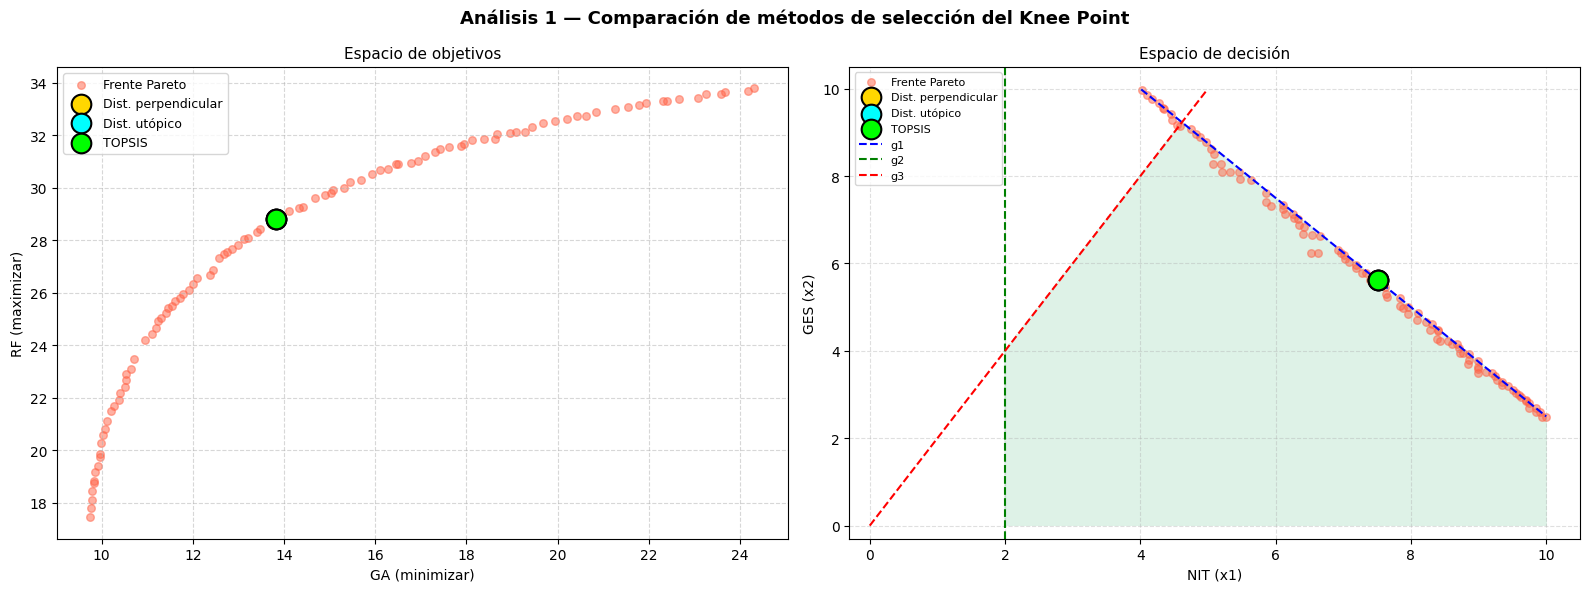

In [32]:
# ── Método 1: Distancia perpendicular (ya calculado) ─────────────────────────
# sol_m_nit, sol_m_ges, sol_m_rf, sol_m_ga  ← ya disponibles

# ── Método 2: Distancia al punto utópico ─────────────────────────────────────
# Utópico: máximo RF normalizado = 1, mínimo GA normalizado = 0
dist_utopico = np.sqrt((rf_norm_m - 1.0)**2 + (ga_norm_m - 0.0)**2)
idx_utopico  = np.argmin(dist_utopico)
u_nit = mod_x1[idx_utopico]; u_ges = mod_x2[idx_utopico]
u_rf  = mod_rf[idx_utopico]; u_ga  = mod_ga[idx_utopico]

# ── Método 3: TOPSIS ──────────────────────────────────────────────────────────
# Ideal: RF norm máximo, GA norm mínimo
# Anti-ideal: RF norm mínimo, GA norm máximo
ideal      = np.array([rf_norm_m.max(), ga_norm_m.min()])
anti_ideal = np.array([rf_norm_m.min(), ga_norm_m.max()])

d_ideal      = np.sqrt((rf_norm_m - ideal[0])**2 + (ga_norm_m - ideal[1])**2)
d_anti_ideal = np.sqrt((rf_norm_m - anti_ideal[0])**2 + (ga_norm_m - anti_ideal[1])**2)
topsis_score = d_anti_ideal / (d_ideal + d_anti_ideal)  # mayor = mejor
idx_topsis   = np.argmax(topsis_score)
t_nit = mod_x1[idx_topsis]; t_ges = mod_x2[idx_topsis]
t_rf  = mod_rf[idx_topsis]; t_ga  = mod_ga[idx_topsis]

# ── Resumen comparativo ───────────────────────────────────────────────────────
print("COMPARACIÓN DE MÉTODOS DE SELECCIÓN — Problema Modificado")
print("=" * 60)
print(f"{'Método':<28} {'NIT':>7} {'GES':>7} {'RF':>8} {'GA':>8}")
print("-" * 60)
print(f"{'Dist. perpendicular':<28} {sol_m_nit:>7.3f} {sol_m_ges:>7.3f} {sol_m_rf:>8.3f} {sol_m_ga:>8.3f}")
print(f"{'Dist. al utópico':<28} {u_nit:>7.3f} {u_ges:>7.3f} {u_rf:>8.3f} {u_ga:>8.3f}")
print(f"{'TOPSIS':<28} {t_nit:>7.3f} {t_ges:>7.3f} {t_rf:>8.3f} {t_ga:>8.3f}")
print("=" * 60)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 1 — Comparación de métodos de selección del Knee Point",
             fontsize=13, fontweight='bold')

colores  = ['gold', 'cyan', 'lime']
metodos  = ['Dist. perpendicular', 'Dist. utópico', 'TOPSIS']
puntos_o = [(sol_m_ga, sol_m_rf), (u_ga, u_rf), (t_ga, t_rf)]
puntos_d = [(sol_m_nit, sol_m_ges), (u_nit, u_ges), (t_nit, t_ges)]

# Panel izquierdo: espacio de objetivos
ax = axes[0]
ax.scatter(mod_ga, mod_rf, s=30, color='tomato', alpha=0.5, label='Frente Pareto')
for (gx, ry), color, label in zip(puntos_o, colores, metodos):
    ax.scatter(gx, ry, s=200, color=color, edgecolors='black', linewidths=1.5,
               zorder=5, label=label)
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("Espacio de objetivos", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.5)

# Panel derecho: espacio de decisión
ax = axes[1]
ax.contourf(X1, X2, factible.astype(float),
            levels=[0.5, 1.5], colors=['#27AE60'], alpha=0.15)
ax.scatter(mod_x1, mod_x2, s=30, color='tomato', alpha=0.5, label='Frente Pareto')
for (nx, gx), color, label in zip(puntos_d, colores, metodos):
    ax.scatter(nx, gx, s=200, color=color, edgecolors='black', linewidths=1.5,
               zorder=5, label=label)
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8, 'b--', lw=1.5, label='g1')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl], 'r--', lw=1.5, label='g3')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## **Análisis 2 — Soluciones infactibles: ¿son mejores?**

El notebook detectó 9 soluciones que violan la restricción g3 (`GES ≤ 2·NIT`).
Antes de descartarlas, conviene responder: ¿ofrecen mejor RF o GA que las factibles?

Si las infactibles dominan a las factibles en objetivos, significa que la restricción 
g3 tiene un coste real en rendimiento y valdría la pena negociarla con el negocio.
Si no dominan, pueden eliminarse sin pérdida.


Soluciones factibles:   91
Soluciones infactibles: 9

 Idx     NIT     GES       RF       GA   g3 violación
-------------------------------------------------------
   1   4.018   9.976   17.438    9.748         1.9390
  27   4.270   9.662   18.452    9.796         1.1223
  28   4.176   9.770   18.090    9.779         1.4186
  30   4.097   9.858   17.787    9.768         1.6643
  32   4.449   9.426   19.170    9.856         0.5287
  34   4.463   9.287   19.392    9.918         0.3607
  75   4.548   9.169   19.731    9.958         0.0739
  83   4.356   9.540   18.811    9.827         0.8284
  98   4.333   9.557   18.738    9.825         0.8909

RF promedio — factibles:   28.680
RF promedio — infactibles: 18.623
GA promedio — factibles:   15.522
GA promedio — infactibles: 9.831


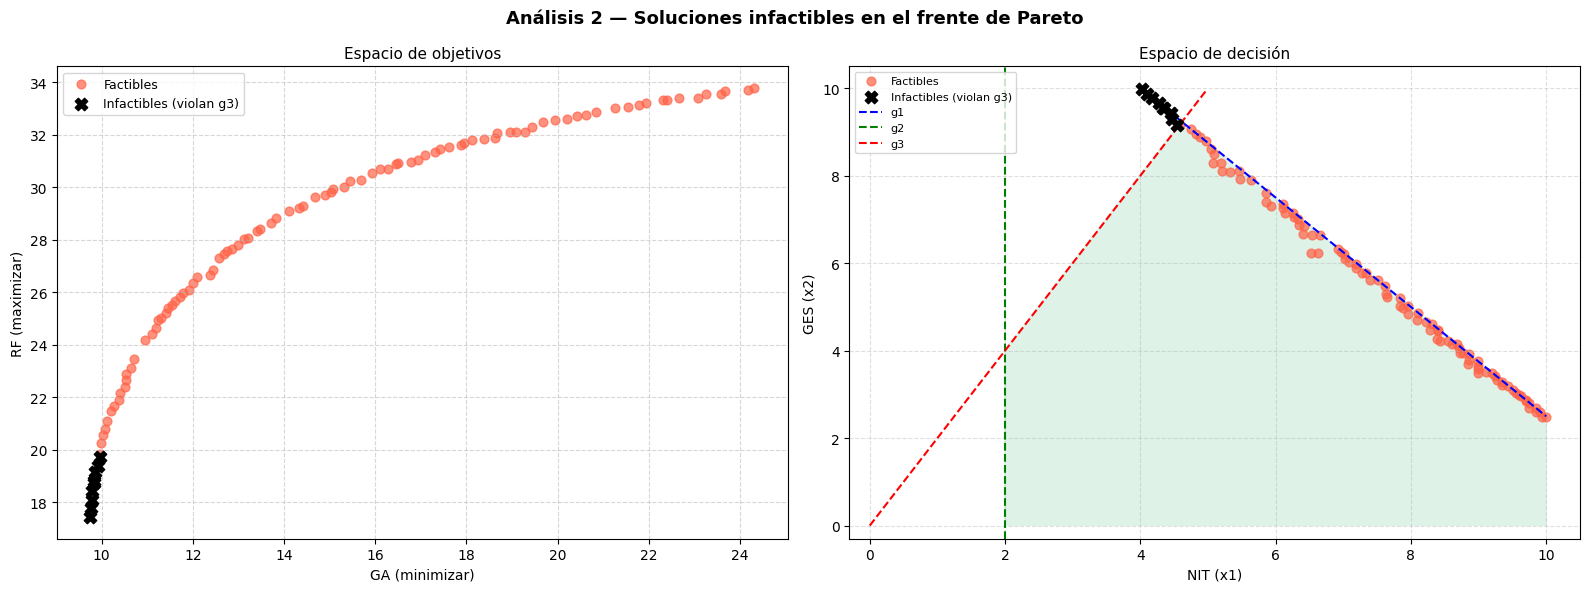

In [33]:
TOL = 1e-6
g1_vals = 1.0 * mod_x1 + 0.8 * mod_x2 - 12.0
g2_vals = 2.0 - mod_x1
g3_vals = mod_x2 - 2.0 * mod_x1

factible_sols  = (g1_vals <= TOL) & (g2_vals <= TOL) & (g3_vals <= TOL)
infactible_idx = np.where(~factible_sols)[0]
factible_idx   = np.where(factible_sols)[0]

print(f"Soluciones factibles:   {factible_idx.size}")
print(f"Soluciones infactibles: {infactible_idx.size}")
print()
print(f"{'Idx':>4} {'NIT':>7} {'GES':>7} {'RF':>8} {'GA':>8} {'g3 violación':>14}")
print("-" * 55)
for i in infactible_idx:
    print(f"{i:>4} {mod_x1[i]:>7.3f} {mod_x2[i]:>7.3f} "
          f"{mod_rf[i]:>8.3f} {mod_ga[i]:>8.3f} {g3_vals[i]:>14.4f}")

print()
print(f"RF promedio — factibles:   {mod_rf[factible_idx].mean():.3f}")
print(f"RF promedio — infactibles: {mod_rf[infactible_idx].mean():.3f}")
print(f"GA promedio — factibles:   {mod_ga[factible_idx].mean():.3f}")
print(f"GA promedio — infactibles: {mod_ga[infactible_idx].mean():.3f}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 2 — Soluciones infactibles en el frente de Pareto",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(mod_ga[factible_idx],   mod_rf[factible_idx],   s=40,
           color='tomato', alpha=0.7, label='Factibles')
ax.scatter(mod_ga[infactible_idx], mod_rf[infactible_idx], s=80,
           color='black', marker='X', zorder=5, label='Infactibles (violan g3)')
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("Espacio de objetivos", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1]
ax.contourf(X1, X2, factible.astype(float),
            levels=[0.5, 1.5], colors=['#27AE60'], alpha=0.15)
ax.scatter(mod_x1[factible_idx],   mod_x2[factible_idx],   s=40,
           color='tomato', alpha=0.7, label='Factibles')
ax.scatter(mod_x1[infactible_idx], mod_x2[infactible_idx], s=80,
           color='black', marker='X', zorder=5, label='Infactibles (violan g3)')
ax.plot(x1_v[mask_pres], (12 - x1_v[mask_pres]) / 0.8, 'b--', lw=1.5, label='g1')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl], 'r--', lw=1.5, label='g3')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## **Análisis 3 — ¿Cuál restricción recorta más el rendimiento?**

Para entender el coste de cada restricción por separado, ejecutamos NSGA-II 
cuatro veces con distintas combinaciones:

| Corrida | Restricciones activas         |
|---------|-------------------------------|
| Base    | Ninguna (problema original)   |
| Sin g1  | Solo g2 y g3                  |
| Sin g2  | Solo g1 y g3                  |
| Sin g3  | Solo g1 y g2                  |
| Todas   | g1 + g2 + g3 (modificado)     |

Comparar los frentes de Pareto resultantes revela qué restricción es la más 
**binding** (la que más limita el espacio de soluciones óptimas).


  Optimizando: Sin g1 (solo g2+g3)...
  Optimizando: Sin g2 (solo g1+g3)...
  Optimizando: Sin g3 (solo g1+g2)...
  Optimizando: Todas (g1+g2+g3)...
  Listo.

Configuración                  RF max   RF min   GA min
-------------------------------------------------------
Original                       121.62    31.00     9.55
Sin g1 (solo g2+g3)             33.79    19.50     9.55
Sin g2 (solo g1+g3)             33.79    19.97     9.94
Sin g3 (solo g1+g2)             33.79    17.36     9.75
Todas (g1+g2+g3)                33.79    19.95     9.94


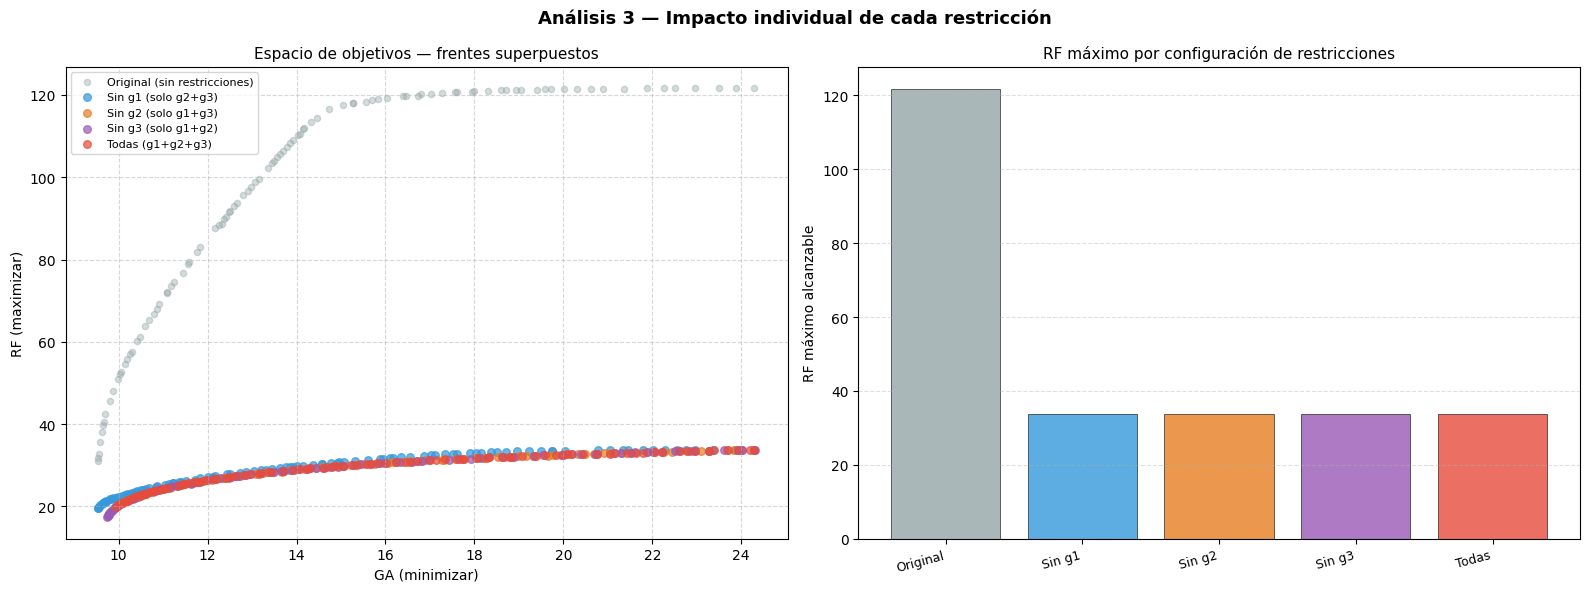

In [34]:
from pymoo.core.problem import ElementwiseProblem

class ProblemaConRestriccionesSelectivas(ElementwiseProblem):
    def __init__(self, usar_g1=True, usar_g2=True, usar_g3=True):
        self.usar_g1 = usar_g1
        self.usar_g2 = usar_g2
        self.usar_g3 = usar_g3
        n_constr = sum([usar_g1, usar_g2, usar_g3])
        super().__init__(n_var=2, n_obj=2, n_constr=n_constr,
                         xl=np.array([0.0, 0.0]), xu=np.array([10.0, 10.0]))

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]
        rf   = 10 * np.sqrt(x1 + 1) + 0.5 * x2 - 0.1 * x2**2
        ga   = 50 / (x2 + 1) + 0.2 * (x1 - 5)**2 + 5
        out["F"] = [-rf, ga]
        g_active = []
        if self.usar_g1: g_active.append(1.0 * x1 + 0.8 * x2 - 12.0)
        if self.usar_g2: g_active.append(2.0 - x1)
        if self.usar_g3: g_active.append(x2 - 2.0 * x1)
        if g_active:
            out["G"] = g_active

configuraciones = {
    'Sin g1 (solo g2+g3)': dict(usar_g1=False, usar_g2=True,  usar_g3=True),
    'Sin g2 (solo g1+g3)': dict(usar_g1=True,  usar_g2=False, usar_g3=True),
    'Sin g3 (solo g1+g2)': dict(usar_g1=True,  usar_g2=True,  usar_g3=False),
    'Todas (g1+g2+g3)':    dict(usar_g1=True,  usar_g2=True,  usar_g3=True),
}

resultados_rest = {}
for nombre, kwargs in configuraciones.items():
    print(f"  Optimizando: {nombre}...")
    prob = ProblemaConRestriccionesSelectivas(**kwargs)
    res  = minimize(prob, crear_algoritmo(), ('n_gen', N_GEN), seed=SEED, verbose=False)
    resultados_rest[nombre] = res
print("  Listo.")

# ── Visualización ─────────────────────────────────────────────────────────────
colores_rest = ['#3498DB', '#E67E22', '#9B59B6', '#E74C3C']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 3 — Impacto individual de cada restricción",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(orig_ga, orig_rf, s=20, color='#95A5A6', alpha=0.4, label='Original (sin restricciones)')
for (nombre, res), color in zip(resultados_rest.items(), colores_rest):
    rf_v = -res.F[:, 0]; ga_v = res.F[:, 1]
    ax.scatter(ga_v, rf_v, s=30, color=color, alpha=0.7, label=nombre)
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("Espacio de objetivos — frentes superpuestos", fontsize=11)
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1]
print(f"\n{'Configuración':<28} {'RF max':>8} {'RF min':>8} {'GA min':>8}")
print("-" * 55)
nombres_all  = ['Original'] + list(resultados_rest.keys())
rf_max_vals  = [orig_rf.max()]
rf_min_vals  = [orig_rf.min()]
ga_min_vals  = [orig_ga.min()]
print(f"{'Original':<28} {orig_rf.max():>8.2f} {orig_rf.min():>8.2f} {orig_ga.min():>8.2f}")
for nombre, res in resultados_rest.items():
    rf_v = -res.F[:, 0]; ga_v = res.F[:, 1]
    rf_max_vals.append(rf_v.max()); rf_min_vals.append(rf_v.min()); ga_min_vals.append(ga_v.min())
    print(f"{nombre:<28} {rf_v.max():>8.2f} {rf_v.min():>8.2f} {ga_v.min():>8.2f}")

x_pos = np.arange(len(nombres_all))
ax.bar(x_pos, rf_max_vals, color=['#95A5A6'] + colores_rest, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Original'] + [n.split('(')[0].strip() for n in resultados_rest.keys()],
                   fontsize=9, rotation=15, ha='right')
ax.set_ylabel("RF máximo alcanzable")
ax.set_title("RF máximo por configuración de restricciones", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


## **Análisis 4 — Métricas de calidad: Hipervolumen y Dispersión**

Comparar visualmente dos frentes de Pareto puede ser subjetivo. Las métricas 
cuantitativas permiten una comparación objetiva:

- **Hipervolumen (HV)**: mide el volumen del espacio dominado por el frente 
  respecto a un punto de referencia. Un HV mayor indica un frente de mejor calidad 
  (soluciones más cercanas al ideal).
- **GD (Generational Distance)**: distancia promedio de cada solución al frente 
  verdadero. Mide convergencia. Valores menores son mejores.
- **Spread (Δ)**: mide qué tan uniformemente distribuidas están las soluciones 
  a lo largo del frente. Un spread bajo indica buena cobertura.

Estas métricas son especialmente útiles para justificar técnicamente cuál 
problema es más difícil de optimizar y cuánto "cuesta" añadir restricciones.


In [15]:
from pymoo.indicators.hv import HV
from pymoo.indicators.gd  import GD
from pymoo.indicators.igd import IGD

# Punto de referencia para HV: peor valor posible en cada objetivo (+ margen)
ref_point = np.array([max(orig_ga.max(), mod_ga.max()) * 1.1,
                      -min(orig_rf.min(), mod_rf.min()) * 1.1])

# pymoo trabaja con objetivos minimizados: F = [-RF, GA]
F_orig = np.column_stack([-orig_rf, orig_ga])
F_mod  = np.column_stack([-mod_rf,  mod_ga])

hv_orig = HV(ref_point=ref_point)(F_orig)
hv_mod  = HV(ref_point=ref_point)(F_mod)

# Spread: distancia promedio entre soluciones consecutivas en el frente ordenado
def calcular_spread(F):
    orden = np.argsort(F[:, 0])
    F_ord = F[orden]
    dists = np.linalg.norm(np.diff(F_ord, axis=0), axis=1)
    return dists.std() / (dists.mean() + 1e-10)

spread_orig = calcular_spread(F_orig)
spread_mod  = calcular_spread(F_mod)

print("MÉTRICAS DE CALIDAD DEL FRENTE DE PARETO")
print("=" * 50)
print(f"{'Métrica':<25} {'Original':>10} {'Modificado':>12}")
print("-" * 50)
print(f"{'Hipervolumen (HV)':<25} {hv_orig:>10.2f} {hv_mod:>12.2f}")
print(f"{'N° soluciones':<25} {len(orig_rf):>10} {len(mod_rf):>12}")
print(f"{'RF máximo':<25} {orig_rf.max():>10.3f} {mod_rf.max():>12.3f}")
print(f"{'RF mínimo':<25} {orig_rf.min():>10.3f} {mod_rf.min():>12.3f}")
print(f"{'GA mínimo':<25} {orig_ga.min():>10.3f} {mod_ga.min():>12.3f}")
print(f"{'Spread (dispersión)':<25} {spread_orig:>10.4f} {spread_mod:>12.4f}")
print("=" * 50)
print(f"\nEl HV del original es {hv_orig/hv_mod:.1f}x mayor que el del modificado.")
print("Esto refleja el coste de imponer las tres restricciones de negocio.")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 4 — Métricas de calidad del frente de Pareto",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(orig_ga, orig_rf, s=35, color='steelblue', alpha=0.6, label=f'Original  HV={hv_orig:.1f}')
ax.scatter(mod_ga,  mod_rf,  s=35, color='tomato',    alpha=0.7, label=f'Modificado HV={hv_mod:.1f}')
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("Frentes superpuestos con HV", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1]
metricas  = ['Hipervolumen', 'RF máximo', 'RF rango\n(max-min)', 'Spread (×10)']
vals_orig = [hv_orig, orig_rf.max(), orig_rf.max()-orig_rf.min(), spread_orig*10]
vals_mod  = [hv_mod,  mod_rf.max(),  mod_rf.max()-mod_rf.min(),  spread_mod*10]
x_pos = np.arange(len(metricas))
w = 0.35
ax.bar(x_pos - w/2, vals_orig, w, label='Original',   color='steelblue', alpha=0.8, edgecolor='black', lw=0.5)
ax.bar(x_pos + w/2, vals_mod,  w, label='Modificado', color='tomato',    alpha=0.8, edgecolor='black', lw=0.5)
ax.set_xticks(x_pos); ax.set_xticklabels(metricas, fontsize=9)
ax.set_title("Comparación de métricas", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


MÉTRICAS DE CALIDAD DEL FRENTE DE PARETO
Métrica                     Original   Modificado
--------------------------------------------------
Hipervolumen (HV)               0.00         0.00
N° soluciones                    100          100
RF máximo                    121.625       33.791
RF mínimo                     31.001       19.945
GA mínimo                      9.545        9.938
Spread (dispersión)           0.8785       0.4168


ZeroDivisionError: float division by zero

## **Análisis 5 — Robustez del algoritmo: varianza entre corridas**

NSGA-II es estocástico: distintas semillas aleatorias producen frentes de 
Pareto ligeramente distintos. Este análisis ejecuta el algoritmo 5 veces con 
semillas diferentes para responder:

- ¿Qué tan estable es la frontera de Pareto entre corridas?
- ¿El knee point siempre apunta a la misma zona de decisión?
- ¿Hay regiones del frente que aparecen en todas las corridas (robustas) 
  vs. regiones que solo aparecen en algunas (inestables)?

Un algoritmo robusto produce frentes muy similares independientemente de la 
semilla, lo que da confianza en que las recomendaciones son reproducibles.


  Semilla 1... OK
  Semilla 42... OK
  Semilla 123... OK
  Semilla 7... OK
  Semilla 99... OK

Semilla |  NIT_orig  GES_orig   RF_orig |   NIT_mod   GES_mod    RF_mod
---------------------------------------------------------------------------
      1 |    10.000     9.590   116.598 |     7.693     5.363    29.289
     42 |    10.000     9.774   116.334 |     7.515     5.600    28.845
    123 |    10.000     9.871   116.181 |     7.536     5.578    28.895
      7 |     9.982     9.988   115.629 |     7.567     5.499    28.995
     99 |    10.000     9.597   116.588 |     7.767     5.290    29.456
---------------------------------------------------------------------------
    std |     0.007     0.155     0.355 |     0.098     0.121     0.237


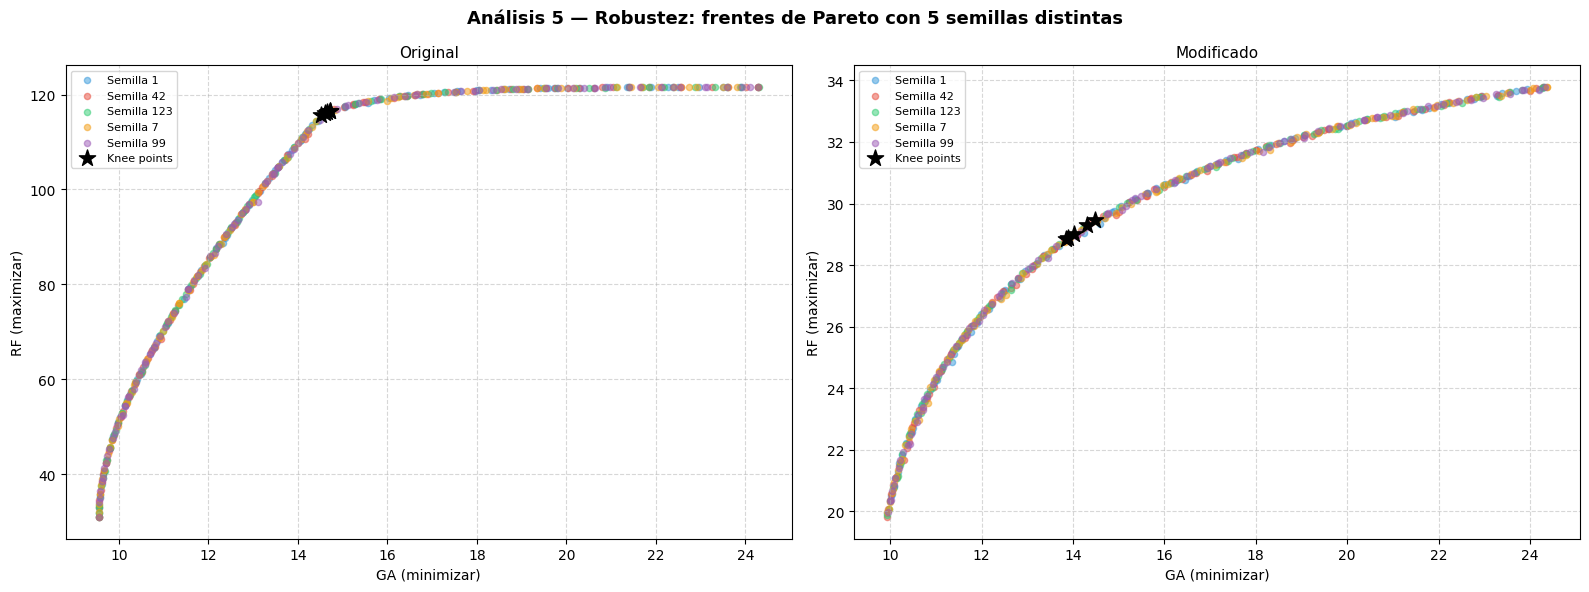

In [36]:
SEMILLAS = [1, 42, 123, 7, 99]

resultados_semillas_orig = []
resultados_semillas_mod  = []

for s in SEMILLAS:
    print(f"  Semilla {s}...", end=' ')
    r_o = minimize(problema_original,  crear_algoritmo(), ('n_gen', N_GEN), seed=s, verbose=False)
    r_m = minimize(problema_modificado, crear_algoritmo(), ('n_gen', N_GEN), seed=s, verbose=False)
    resultados_semillas_orig.append(r_o)
    resultados_semillas_mod.append(r_m)
    print("OK")

# ── Knee point por semilla ────────────────────────────────────────────────────
def knee_point(rf_vals, ga_vals, x1_vals, x2_vals):
    rf_n = (rf_vals - rf_vals.min()) / (rf_vals.max() - rf_vals.min() + 1e-10)
    ga_n = (ga_vals - ga_vals.min()) / (ga_vals.max() - ga_vals.min() + 1e-10)
    A = np.array([ga_n[np.argmax(rf_n)], rf_n[np.argmax(rf_n)]])
    B = np.array([ga_n[np.argmin(ga_n)], rf_n[np.argmin(ga_n)]])
    dists = np.array([distancia_a_linea(np.array([ga_n[i], rf_n[i]]), A, B) for i in range(len(rf_vals))])
    idx = np.argmax(dists)
    return x1_vals[idx], x2_vals[idx], rf_vals[idx], ga_vals[idx]

print(f"\n{'Semilla':>7} | {'NIT_orig':>9} {'GES_orig':>9} {'RF_orig':>9} | "
      f"{'NIT_mod':>9} {'GES_mod':>9} {'RF_mod':>9}")
print("-" * 75)
knees_orig = []; knees_mod = []
for s, r_o, r_m in zip(SEMILLAS, resultados_semillas_orig, resultados_semillas_mod):
    rf_o = -r_o.F[:,0]; ga_o = r_o.F[:,1]
    rf_m = -r_m.F[:,0]; ga_m = r_m.F[:,1]
    x1_o, x2_o = r_o.X[:,0], r_o.X[:,1]
    x1_m, x2_m = r_m.X[:,0], r_m.X[:,1]
    ko = knee_point(rf_o, ga_o, x1_o, x2_o)
    km = knee_point(rf_m, ga_m, x1_m, x2_m)
    knees_orig.append(ko); knees_mod.append(km)
    print(f"{s:>7} | {ko[0]:>9.3f} {ko[1]:>9.3f} {ko[2]:>9.3f} | "
          f"{km[0]:>9.3f} {km[1]:>9.3f} {km[2]:>9.3f}")

knees_orig = np.array(knees_orig); knees_mod = np.array(knees_mod)
print("-" * 75)
print(f"{'std':>7} | {knees_orig[:,0].std():>9.3f} {knees_orig[:,1].std():>9.3f} "
      f"{knees_orig[:,2].std():>9.3f} | {knees_mod[:,0].std():>9.3f} "
      f"{knees_mod[:,1].std():>9.3f} {knees_mod[:,2].std():>9.3f}")

# ── Visualización ─────────────────────────────────────────────────────────────
colores_sem = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 5 — Robustez: frentes de Pareto con 5 semillas distintas",
             fontsize=13, fontweight='bold')

for ax, resultados, titulo, knees in zip(
        axes,
        [resultados_semillas_orig, resultados_semillas_mod],
        ['Original', 'Modificado'],
        [knees_orig, knees_mod]):
    for r, s, color in zip(resultados, SEMILLAS, colores_sem):
        rf_v = -r.F[:,0]; ga_v = r.F[:,1]
        ax.scatter(ga_v, rf_v, s=20, color=color, alpha=0.5, label=f'Semilla {s}')
    ax.scatter(knees[:,3], knees[:,2], s=150, color='black', marker='*',
               zorder=5, label='Knee points')
    ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## **Análisis 6 — ¿Cuánto se pierde por operar bajo restricciones?**

El knee point del problema original representa la mejor estrategia posible en 
un mundo sin límites. Al imponer las tres restricciones del negocio, esa 
solución puede volverse infactible o subóptima.

Este análisis encuentra la solución factible del problema modificado más 
cercana en el espacio de decisión al knee point del original, y cuantifica 
exactamente cuánto RF y GA se sacrifican por operar bajo restricciones reales.
La diferencia es el **costo de la factibilidad**.


COSTO REAL DE LAS RESTRICCIONES
                              NIT     GES       RF       GA
-------------------------------------------------------
Knee original              10.000   9.590  116.598   14.721
Equiv. factible (mod.)      6.652   6.638   26.575   12.092
-------------------------------------------------------
Diferencia (costo)         -3.348  -2.952  -90.023   -2.629

  Pérdida de RF: 90.02 (77.2%)
  Cambio en GA:  -2.63 (mejora)


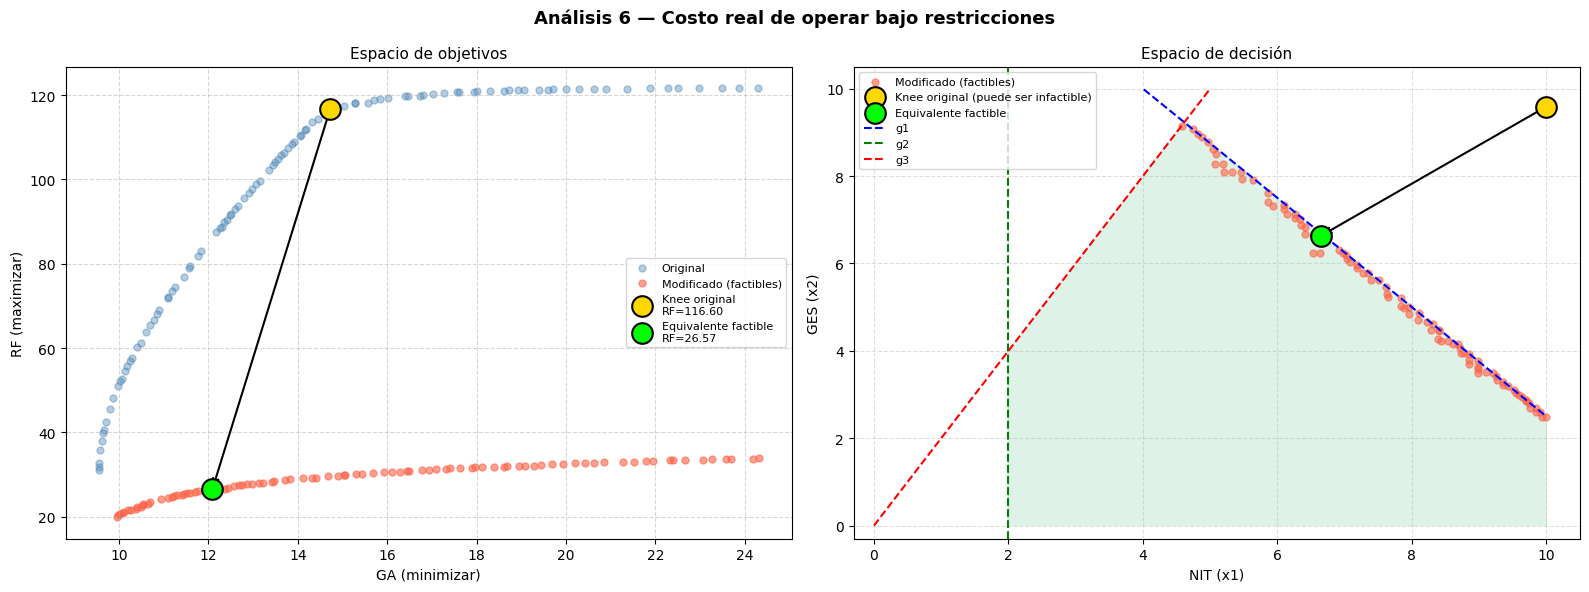

In [37]:
# Knee point del original (en espacio de decisión)
kp_orig_nit = sol_o_nit; kp_orig_ges = sol_o_ges

# Soluciones factibles del modificado
TOL = 1e-6
g1v = 1.0*mod_x1 + 0.8*mod_x2 - 12.0
g2v = 2.0 - mod_x1
g3v = mod_x2 - 2.0*mod_x1
mask_fact = (g1v <= TOL) & (g2v <= TOL) & (g3v <= TOL)

mod_x1_f = mod_x1[mask_fact]; mod_x2_f = mod_x2[mask_fact]
mod_rf_f  = mod_rf[mask_fact]; mod_ga_f  = mod_ga[mask_fact]

# Distancia euclidiana en espacio de decisión normalizado
x1_range = 10.0; x2_range = 10.0
dist_dec = np.sqrt(((mod_x1_f - kp_orig_nit)/x1_range)**2 +
                   ((mod_x2_f - kp_orig_ges)/x2_range)**2)
idx_cerca = np.argmin(dist_dec)

equiv_nit = mod_x1_f[idx_cerca]; equiv_ges = mod_x2_f[idx_cerca]
equiv_rf  = mod_rf_f[idx_cerca]; equiv_ga  = mod_ga_f[idx_cerca]

print("COSTO REAL DE LAS RESTRICCIONES")
print("=" * 55)
print(f"{'':25} {'NIT':>7} {'GES':>7} {'RF':>8} {'GA':>8}")
print("-" * 55)
print(f"{'Knee original':<25} {kp_orig_nit:>7.3f} {kp_orig_ges:>7.3f} "
      f"{sol_o_rf:>8.3f} {sol_o_ga:>8.3f}")
print(f"{'Equiv. factible (mod.)':<25} {equiv_nit:>7.3f} {equiv_ges:>7.3f} "
      f"{equiv_rf:>8.3f} {equiv_ga:>8.3f}")
print("-" * 55)
print(f"{'Diferencia (costo)':<25} {equiv_nit-kp_orig_nit:>7.3f} "
      f"{equiv_ges-kp_orig_ges:>7.3f} "
      f"{equiv_rf-sol_o_rf:>8.3f} {equiv_ga-sol_o_ga:>8.3f}")
print(f"\n  Pérdida de RF: {abs(equiv_rf - sol_o_rf):.2f} "
      f"({abs(equiv_rf - sol_o_rf)/sol_o_rf*100:.1f}%)")
print(f"  Cambio en GA:  {equiv_ga - sol_o_ga:+.2f} "
      f"({'mejora' if equiv_ga < sol_o_ga else 'empeora'})")
print("=" * 55)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis 6 — Costo real de operar bajo restricciones",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(orig_ga, orig_rf, s=25, color='steelblue', alpha=0.4, label='Original')
ax.scatter(mod_ga_f, mod_rf_f, s=25, color='tomato', alpha=0.6, label='Modificado (factibles)')
ax.scatter(sol_o_ga, sol_o_rf, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Knee original\nRF={sol_o_rf:.2f}')
ax.scatter(equiv_ga, equiv_rf, s=220, color='lime', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Equivalente factible\nRF={equiv_rf:.2f}')
ax.annotate('', xy=(equiv_ga, equiv_rf), xytext=(sol_o_ga, sol_o_rf),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.set_xlabel("GA (minimizar)"); ax.set_ylabel("RF (maximizar)")
ax.set_title("Espacio de objetivos", fontsize=11)
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1]
ax.contourf(X1, X2, factible.astype(float),
            levels=[0.5, 1.5], colors=['#27AE60'], alpha=0.15)
ax.scatter(mod_x1_f, mod_x2_f, s=25, color='tomato', alpha=0.6, label='Modificado (factibles)')
ax.scatter(kp_orig_nit, kp_orig_ges, s=220, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label='Knee original (puede ser infactible)')
ax.scatter(equiv_nit, equiv_ges, s=220, color='lime', edgecolors='black',
           linewidths=1.5, zorder=5, label='Equivalente factible')
ax.annotate('', xy=(equiv_nit, equiv_ges), xytext=(kp_orig_nit, kp_orig_ges),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.plot(x1_v[mask_pres], (12-x1_v[mask_pres])/0.8, 'b--', lw=1.5, label='g1')
ax.axvline(2, color='green', lw=1.5, linestyle='--', label='g2')
ax.plot(x1_v[mask_ctrl], 2*x1_v[mask_ctrl], 'r--', lw=1.5, label='g3')
ax.set_xlabel("NIT (x1)"); ax.set_ylabel("GES (x2)")
ax.set_title("Espacio de decisión", fontsize=11)
ax.set_xlim(-0.3, 10.5); ax.set_ylim(-0.3, 10.5)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## **Análisis 7 — ¿Qué tan activa es la restricción presupuestaria?**

Una restricción es **activa** (o *binding*) cuando la mayoría de las soluciones 
óptimas se acumulan exactamente en su límite. Si la restricción presupuestaria 
`x1 + 0.8·x2 ≤ 12` es activa, significa que el algoritmo siempre quiere gastar 
más pero no puede: el presupuesto es el cuello de botella real del problema.

Si en cambio las soluciones se distribuyen lejos del límite, la restricción 
presupuestaria tiene holgura y no está condicionando las decisiones.

Este análisis cuantifica la holgura de las tres restricciones y determina 
cuál de ellas es realmente la que más condiciona el espacio óptimo.


ANÁLISIS DE RESTRICCIONES ACTIVAS (umbral holgura < 0.5)
Restricción                     Holgura media   % activa
-------------------------------------------------------
g1: presupuesto (≤12)                   0.085     100.0%
g2: NIT mínimo (≥2)                     5.327       0.0%
g3: GES ≤ 2·NIT                         8.917      11.0%

Restriccón más binding: g1 (presupuesto) (100.0% de soluciones cerca del límite)


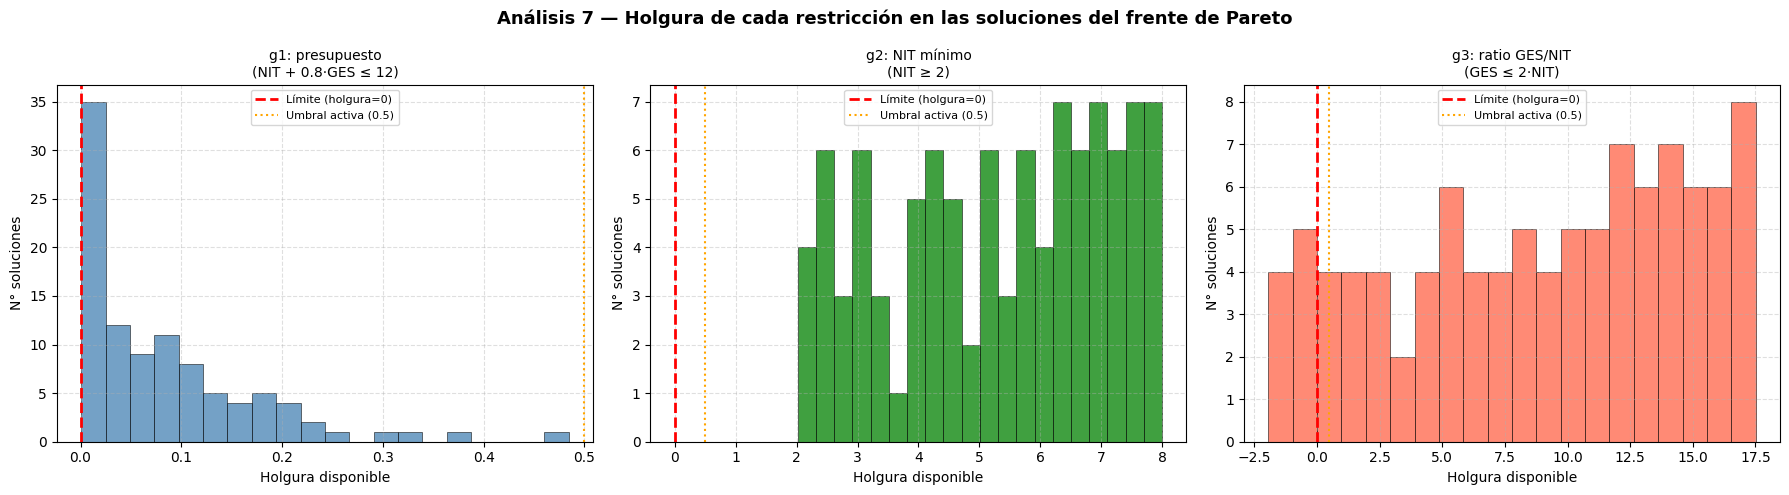

In [38]:
TOL = 1e-6
g1v = 1.0*mod_x1 + 0.8*mod_x2 - 12.0   # presupuesto   (≤ 0)
g2v = 2.0 - mod_x1                        # NIT mínimo    (≤ 0)
g3v = mod_x2 - 2.0*mod_x1                # control ratio (≤ 0)

# Holgura = cuánto margen queda antes de violar la restricción (valor absoluto)
holgura_g1 = -g1v   # positivo = margen disponible
holgura_g2 = -g2v
holgura_g3 = -g3v

UMBRAL = 0.5  # consideramos "activa" si la holgura es menor a 0.5 unidades
pct_activa_g1 = (holgura_g1 < UMBRAL).mean() * 100
pct_activa_g2 = (holgura_g2 < UMBRAL).mean() * 100
pct_activa_g3 = (holgura_g3 < UMBRAL).mean() * 100

print("ANÁLISIS DE RESTRICCIONES ACTIVAS (umbral holgura < 0.5)")
print("=" * 55)
print(f"{'Restricción':<30} {'Holgura media':>14} {'% activa':>10}")
print("-" * 55)
print(f"{'g1: presupuesto (≤12)':<30} {holgura_g1.mean():>14.3f} {pct_activa_g1:>9.1f}%")
print(f"{'g2: NIT mínimo (≥2)':<30} {holgura_g2.mean():>14.3f} {pct_activa_g2:>9.1f}%")
print(f"{'g3: GES ≤ 2·NIT':<30} {holgura_g3.mean():>14.3f} {pct_activa_g3:>9.1f}%")
print("=" * 55)
restriccion_binding = max(
    [('g1 (presupuesto)', pct_activa_g1),
     ('g2 (NIT mínimo)',  pct_activa_g2),
     ('g3 (ratio GES/NIT)', pct_activa_g3)],
    key=lambda x: x[1])
print(f"\nRestriccón más binding: {restriccion_binding[0]} "
      f"({restriccion_binding[1]:.1f}% de soluciones cerca del límite)")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis 7 — Holgura de cada restricción en las soluciones del frente de Pareto",
             fontsize=13, fontweight='bold')

datos = [
    (holgura_g1, 'steelblue', 'g1: presupuesto\n(NIT + 0.8·GES ≤ 12)', 12.0 - (1.0*mod_x1 + 0.8*mod_x2)),
    (holgura_g2, 'green',     'g2: NIT mínimo\n(NIT ≥ 2)',              mod_x1 - 2.0),
    (holgura_g3, 'tomato',    'g3: ratio GES/NIT\n(GES ≤ 2·NIT)',       2.0*mod_x1 - mod_x2),
]

for ax, (holgura, color, titulo, _) in zip(axes, datos):
    ax.hist(holgura, bins=20, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='red', lw=2, linestyle='--', label='Límite (holgura=0)')
    ax.axvline(UMBRAL, color='orange', lw=1.5, linestyle=':', label=f'Umbral activa ({UMBRAL})')
    ax.set_xlabel("Holgura disponible"); ax.set_ylabel("N° soluciones")
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
